In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import gc
from pathlib import Path
import netCDF4 as nc
from datetime import datetime
import re
from datetime import timedelta
from scipy.ndimage import gaussian_filter1d

In [2]:
gemlam_dir = "/results/forcing/atmospheric/GEM2.5/gemlam"
operational_dir = "/results/forcing/atmospheric/GEM2.5/operational"
time_fixed_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed"

gemlam_start = datetime(2007, 1, 3)
gemlam_end = datetime(2014, 9, 30)
ops_start = datetime(2014, 10, 1)
ops_end = datetime(2021, 12, 31)

years = range(2007, 2022)

fixed_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    "gemlam_y2008m08d10.nc",
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
    "gemlam_y2012m10d04.nc"   
}

def get_file_date(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r"_y(\d{4})m(\d{2})d(\d{2})", filename)
    if match is None:
        return None
    year, month, day = map(int, match.groups())
    return datetime(year, month, day)

all_gemlam_files = glob.glob(os.path.join(gemlam_dir, "*.nc"))
all_ops_files = glob.glob(os.path.join(operational_dir, "ops_y????m??d??.nc"))

selected_gemlam_files = {}

for filepath in all_gemlam_files:
    file_date = get_file_date(filepath)
    if file_date is not None and gemlam_start <= file_date <= gemlam_end:
        selected_gemlam_files[file_date] = filepath

for filename in fixed_filenames:
    fixed_filepath = os.path.join(time_fixed_dir, filename)
    if not os.path.exists(fixed_filepath):
        raise FileNotFoundError(f"Corrected file not found: {fixed_filepath}")
    fixed_date = get_file_date(fixed_filepath)
    if fixed_date is None:
        raise ValueError(f"Could not extract date from: {fixed_filepath}")
    selected_gemlam_files[fixed_date] = fixed_filepath

selected_ops_files = {}

for filepath in all_ops_files:
    file_date = get_file_date(filepath)
    if file_date is not None and ops_start <= file_date <= ops_end:
        selected_ops_files[file_date] = filepath

all_selected_files = {**selected_gemlam_files, **selected_ops_files}

hrdps_files_by_year = {}

for year in years:
    files = [filepath for file_date, filepath in sorted(all_selected_files.items()) if file_date.year == year]
    if len(files) == 0:
        print(f"{year}: no files found")
        continue
    hrdps_files_by_year[year] = files
    print(year, ":", files[0], "to", files[-1], f"({len(files)} files)")

2007 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d03.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m12d31.nc (363 files)
2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)
2013 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2013m01d01.nc to /results/forc

In [3]:
# Loading datasets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()
 
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [4]:
transition_time = pd.Timestamp("2011-09-22 00:00:00")
wind_component_names = ["u_wind","v_wind"]

def interpolate_wind_component_with_weights(wind_component,ds_weights,variable_name,):
    wind_component = wind_component.transpose("time_counter","y","x",)
    n_time = wind_component.sizes["time_counter"]
    source_shape = (wind_component.sizes["y"],wind_component.sizes["x"],)
    n_source_cells = (source_shape[0] * source_shape[1])
    source_values = (wind_component.values.reshape(n_time,n_source_cells,).astype(np.float32))
    target_shape = ds_weights["src01"].shape
    interpolated = np.zeros((n_time,target_shape[0],target_shape[1],),dtype=np.float32,)

    for n in range(1, 5):
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1 )
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))
        interpolated += (source_values[:, source_index]* weight[None, :, :])

    wind_nemo = xr.DataArray(
        interpolated,dims=("time_counter","y","x",),
        coords={"time_counter":wind_component["time_counter"],"nav_lat": (("y", "x"),nemo_lat.values,),"nav_lon": (("y", "x"),nemo_lon.values,),},
        name=variable_name,)

    wind_nemo.attrs = (wind_component.attrs.copy())
    wind_nemo.attrs["grid"] = ("SalishSeaCast NEMO grid")
    wind_nemo.attrs["interpolation"] = ("Four-source weighted HRDPS-to-NEMO interpolation")
    return wind_nemo

In [5]:
def extract_and_interpolate_hourly_wind(file):
    with xr.open_dataset(file) as ds:
        wind = (ds[wind_component_names].sortby("time_counter"))
        time_index = wind.get_index("time_counter")
        if time_index.has_duplicates:
            unique_mask = (~time_index.duplicated())
            wind = wind.isel(time_counter=unique_mask)
        wind = wind.load()
    times = pd.to_datetime(wind["time_counter"].values)
    before_transition = (times < transition_time)
    after_transition = (times >= transition_time)
    interpolated_pieces = []
    if before_transition.any():
        wind_pre = wind.isel(time_counter=np.where(before_transition)[0])
        pre_dataset = xr.Dataset({
                variable_name:
                    interpolate_wind_component_with_weights(
                        wind_pre[variable_name],
                        ds_weights_pre,
                        variable_name,
                    )
                for variable_name
                in wind_component_names})
        interpolated_pieces.append(pre_dataset)

    if after_transition.any():
        wind_post = wind.isel(time_counter=np.where(after_transition)[0])
        post_dataset = xr.Dataset({
                variable_name:
                    interpolate_wind_component_with_weights(
                        wind_post[variable_name],
                        ds_weights_post,
                        variable_name,
                    )
                for variable_name
                in wind_component_names})
        interpolated_pieces.append(post_dataset)

    wind_nemo = xr.concat(interpolated_pieces,dim="time_counter",).sortby("time_counter")
    return wind_nemo

In [6]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = (ds_mesh["nav_lat"].load().values)
    nemo_lon_2d = (ds_mesh["nav_lon"].load().values)

nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = (nemo_lat_2d[water_mask])
nemo_water_lon = (nemo_lon_2d[water_mask])
n_water = len(water_flat_indices)
print("NEMO grid shape:",water_mask.shape)
print("Number of surface water cells:",n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [7]:
def process_daily_file_to_3h_water(file):
    wind_nemo_hourly = (extract_and_interpolate_hourly_wind(file))
    n_time = wind_nemo_hourly.sizes[ "time_counter"]
    water_components = {}
    for variable_name in wind_component_names:
        component_values = (wind_nemo_hourly[variable_name].values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
        component_water_hourly = xr.DataArray(component_values,dims=("time_counter","water_cell",),
            coords={"time_counter":wind_nemo_hourly["time_counter"].values,"water_cell":np.arange(n_water,dtype=np.int32,),},
            name=variable_name,
            attrs=(wind_nemo_hourly[variable_name].attrs),)
        water_components[variable_name] = (component_water_hourly)

    wind_water_hourly = xr.Dataset(water_components)

    wind_water_3h = (wind_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean())
    return wind_water_3h.load()

In [8]:
test_file = (hrdps_files_by_year[2008][0])
test_3h = (process_daily_file_to_3h_water(test_file))
print(test_3h)
print("U shape:",test_3h["u_wind"].shape,)
print("V shape:",test_3h["v_wind"].shape,)
print("Times:",test_3h.time_counter.values,)

<xarray.Dataset> Size: 6MB
Dimensions:       (time_counter: 8, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
Data variables:
    u_wind        (time_counter, water_cell) float32 3MB -2.045 ... 0.4804
    v_wind        (time_counter, water_cell) float32 3MB -1.719 ... -0.3571
U shape: (8, 81383)
V shape: (8, 81383)
Times: ['2008-01-01T00:00:00.000000000' '2008-01-01T03:00:00.000000000'
 '2008-01-01T06:00:00.000000000' '2008-01-01T09:00:00.000000000'
 '2008-01-01T12:00:00.000000000' '2008-01-01T15:00:00.000000000'
 '2008-01-01T18:00:00.000000000' '2008-01-01T21:00:00.000000000']


In [9]:
test_file = (hrdps_files_by_year[2019][0])
test_3h = (process_daily_file_to_3h_water(test_file))
print(test_3h)
print("U shape:",test_3h["u_wind"].shape,)
print("V shape:",test_3h["v_wind"].shape,)
print("Times:",test_3h.time_counter.values,)

<xarray.Dataset> Size: 6MB
Dimensions:       (time_counter: 8, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2019-01-01 ... 2019-01-01...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
Data variables:
    u_wind        (time_counter, water_cell) float32 3MB -0.1993 ... 0.9112
    v_wind        (time_counter, water_cell) float32 3MB -1.429 -1.447 ... 0.663
U shape: (8, 81383)
V shape: (8, 81383)
Times: ['2019-01-01T00:00:00.000000000' '2019-01-01T03:00:00.000000000'
 '2019-01-01T06:00:00.000000000' '2019-01-01T09:00:00.000000000'
 '2019-01-01T12:00:00.000000000' '2019-01-01T15:00:00.000000000'
 '2019-01-01T18:00:00.000000000' '2019-01-01T21:00:00.000000000']


In [10]:
# #Run only once

# output_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_wind_3h")
# os.makedirs(output_dir,exist_ok=True)
# years = list(range(2007, 2022))
# hrdps_nemo_processed_files = []
# for year in years:
#     files = sorted(hrdps_files_by_year[year])
#     print(f"\nProcessing {year}: {len(files)} daily files")
#     daily_3h_results = []
#     for file_number, file in enumerate(files,start=1):
#         daily_3h = (process_daily_file_to_3h_water(file))
#         daily_3h_results.append(daily_3h)
#         if (file_number == 1 or file_number % 25 == 0 or file_number == len(files)):
#             print(f"{year}: processed {file_number}/{len(files)} files")

#     wind_year = xr.concat(daily_3h_results,dim="time_counter")
#     wind_year = wind_year.sortby("time_counter")
#     time_index = wind_year.get_index("time_counter")
#     if time_index.has_duplicates:
#         unique_mask = (~time_index.duplicated())
#         wind_year = wind_year.isel(time_counter=unique_mask)

#     wind_year = wind_year.assign_coords(
#         nemo_j=("water_cell",nemo_j.astype(np.int32)),
#         nemo_i=("water_cell",nemo_i.astype(np.int32)),
#         nav_lat=("water_cell",nemo_water_lat.astype(np.float32)),
#         nav_lon=("water_cell",nemo_water_lon.astype(np.float32)))

#     wind_year.attrs["description"] = ("Raw hourly HRDPS u_wind and v_wind interpolated onto NEMO surface water cells, then resampled to three-hourly means.")
#     output_file = (f"{output_dir}/" f"HRDPS_NEMO_{year}_wind_3h.nc")
#     encoding = {"u_wind": {"dtype": "float32","zlib": True,"complevel": 4,},"v_wind": {"dtype": "float32","zlib": True,"complevel": 4,},}
#     wind_year.to_netcdf(output_file,engine="netcdf4",encoding=encoding,)
#     hrdps_nemo_processed_files.append(output_file)
#     print("Saved:", output_file)
#     print("U shape:",wind_year["u_wind"].shape)
#     print("V shape:",wind_year["v_wind"].shape)
#     print("Time range:",wind_year.time_counter.values[0],"to",wind_year.time_counter.values[-1],)

#     del daily_3h_results
#     del wind_year

#     gc.collect()

In [11]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_wind_3h/HRDPS_NEMO_*_wind_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files,combine="by_coords",)
ds_hrdps_nemo = (ds_hrdps_nemo.sortby("time_counter"))
print(ds_hrdps_nemo)
print("First time:",ds_hrdps_nemo.time_counter.values[0],)
print("Last time:",ds_hrdps_nemo.time_counter.values[-1],)
print("U shape:",ds_hrdps_nemo["u_wind"].shape,)
print("V shape:",ds_hrdps_nemo["v_wind"].shape,)

<xarray.Dataset> Size: 29GB
Dimensions:       (time_counter: 43816, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 351kB 2007-01-03 ... 2021-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    u_wind        (time_counter, water_cell) float32 14GB dask.array<chunksize=(363, 10173), meta=np.ndarray>
    v_wind        (time_counter, water_cell) float32 14GB dask.array<chunksize=(363, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS u_wind and v_wind interpolated onto NEMO s...
First time: 2007-01-03T00:00:00.000000000

In [12]:
train_years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
validation_years = [2007, 2008, 2009]
test_years = [2019, 2020, 2021]

In [13]:
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(train_years))
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(validation_years))
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=ds_hrdps_nemo.time_counter.dt.year.isin(test_years))

In [14]:
canrcm_years = [2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
canrcm_uas_files = []
canrcm_vas_files = []
for year in canrcm_years:
    uas_matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_uas.nc"))
    vas_matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_vas.nc"))
    canrcm_uas_files.append(uas_matches[0])
    canrcm_vas_files.append(vas_matches[0])

print("CanRCM uas files:")
for file in canrcm_uas_files:
    print(file)
print("CanRCM vas files:")
for file in canrcm_vas_files:
    print(file)

CanRCM uas files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200701_200712_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201301_201312_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201401_201412_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201501_201512_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201601_201612_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201701_201712_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201801_201812_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201901_201912_3h_uas.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_202001_202012_3h_uas.nc
/r

In [15]:
ds_canrcm_uas = xr.open_mfdataset(canrcm_uas_files,combine="by_coords",)[["uas"]]
ds_canrcm_vas = xr.open_mfdataset(canrcm_vas_files,combine="by_coords",)[["vas"]]

ds_canrcm_uas, ds_canrcm_vas = xr.align(ds_canrcm_uas,ds_canrcm_vas,join="inner")
ds_canrcm = xr.merge([ds_canrcm_uas,ds_canrcm_vas,],compat="override")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3) for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=( "time",shifted_time))
print(ds_canrcm)
print("First timestamp:",ds_canrcm.time.values[0])
print("Last timestamp:",ds_canrcm.time.values[-1])

/tmp/ipykernel_3385143/1102125186.py:1: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm_uas = xr.open_mfdataset(canrcm_uas_files,combine="by_coords",)[["uas"]]
/tmp/ipykernel_3385143/1102125186.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm_vas = xr.open_mfdataset(canrcm_vas_files,combine

<xarray.Dataset> Size: 40GB
Dimensions:  (time: 43800, rlat: 320, rlon: 360)
Coordinates:
  * time     (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:00:00
  * rlat     (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon     (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon      (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat      (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Data variables:
    uas      (time, rlat, rlon) float32 20GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
    vas      (time, rlat, rlon) float32 20GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_mo

In [16]:
nemo_water_lat = (ds_hrdps_nemo["nav_lat"].values)
nemo_water_lon = (ds_hrdps_nemo["nav_lon"].values)
nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180
lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))
lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax( nemo_water_lon_normalized))
print( "NEMO latitude range:",lat_min,"to",lat_max)
print("NEMO longitude range:",lon_min,"to",lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [17]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
    & (lon_canrcm_normalized>= lon_min)& (lon_canrcm_normalized<= lon_max))

rlat_indices, rlon_indices = (np.where(canrcm_region_mask.values))
rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()
rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()
print("CanRCM rlat indices:",rlat_min,"to",rlat_max)
print("CanRCM rlon indices:",rlon_min,"to",rlon_max)
ds_canrcm_cut = (ds_canrcm[["uas","vas"]].isel(rlat=slice(rlat_min,rlat_max + 1),rlon=slice(rlon_min,rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 119MB
Dimensions:  (time: 43800, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 350kB 2007-01-01 00:00:00 ... 2021-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    uas      (time, rlat, rlon) float32 60MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
    vas      (time, rlat, rlon) float32 60MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    d

In [18]:
ds_canrcm_train = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(train_years))
ds_canrcm_val = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(validation_years))
ds_canrcm_test = ds_canrcm_cut.sel(time=ds_canrcm_cut.time.dt.year.isin(test_years))

In [19]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")

    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")

    raise TypeError(f"Unsupported time type: {type(value)}")


def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(t)for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t)for t in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [20]:
canrcm_times = np.array([time_to_string(time) for time in ds_canrcm_val["time"].values])
hrdps_times = np.array([time_to_string(time) for time in ds_hrdps_val["time_counter"].values])

canrcm_not_in_hrdps = np.setdiff1d(canrcm_times, hrdps_times)
hrdps_not_in_canrcm = np.setdiff1d(hrdps_times, canrcm_times)

print("CanRCM timestamps not in HRDPS:", len(canrcm_not_in_hrdps))
print(canrcm_not_in_hrdps)

print("\nHRDPS timestamps not in CanRCM:", len(hrdps_not_in_canrcm))
print(hrdps_not_in_canrcm)

CanRCM timestamps not in HRDPS: 16
['2007-01-01 00:00:00' '2007-01-01 03:00:00' '2007-01-01 06:00:00'
 '2007-01-01 09:00:00' '2007-01-01 12:00:00' '2007-01-01 15:00:00'
 '2007-01-01 18:00:00' '2007-01-01 21:00:00' '2007-01-02 00:00:00'
 '2007-01-02 03:00:00' '2007-01-02 06:00:00' '2007-01-02 09:00:00'
 '2007-01-02 12:00:00' '2007-01-02 15:00:00' '2007-01-02 18:00:00'
 '2007-01-02 21:00:00']

HRDPS timestamps not in CanRCM: 8
['2008-02-29 00:00:00' '2008-02-29 03:00:00' '2008-02-29 06:00:00'
 '2008-02-29 09:00:00' '2008-02-29 12:00:00' '2008-02-29 15:00:00'
 '2008-02-29 18:00:00' '2008-02-29 21:00:00']


In [21]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)

In [22]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])
print("Training:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])
print("Testing:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])

Validation:
HRDPS: 8744
CanRCM: 8744
Training:
HRDPS: 26280
CanRCM: 26280
Testing:
HRDPS: 8760
CanRCM: 8760


In [23]:
X_hrdps_u_train_raw = ds_hrdps_train["u_wind"].values.astype(np.float32)
X_hrdps_u_val_raw = ds_hrdps_val["u_wind"].values.astype(np.float32)
X_hrdps_u_test_raw = ds_hrdps_test["u_wind"].values.astype(np.float32)
X_hrdps_v_train_raw = ds_hrdps_train["v_wind"].values.astype(np.float32)
X_hrdps_v_val_raw = ds_hrdps_val["v_wind"].values.astype(np.float32)
X_hrdps_v_test_raw = ds_hrdps_test["v_wind"].values.astype(np.float32)
print("Raw HRDPS U train:", X_hrdps_u_train_raw.shape)
print("Raw HRDPS V train:", X_hrdps_v_train_raw.shape)
print("Raw HRDPS U val:", X_hrdps_u_val_raw.shape)
print("Raw HRDPS V val:", X_hrdps_v_val_raw.shape)
print("Raw HRDPS U test:", X_hrdps_u_test_raw.shape)
print("Raw HRDPS V test:", X_hrdps_v_test_raw.shape)

Raw HRDPS U train: (26280, 81383)
Raw HRDPS V train: (26280, 81383)
Raw HRDPS U val: (8744, 81383)
Raw HRDPS V val: (8744, 81383)
Raw HRDPS U test: (8760, 81383)
Raw HRDPS V test: (8760, 81383)


In [24]:
def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X

In [25]:
valid_fraction_hrdps_u = np.isfinite(X_hrdps_u_train_raw).mean(axis=0)
valid_fraction_hrdps_v = np.isfinite(X_hrdps_v_train_raw).mean(axis=0)

valid_nemo_cols = (valid_fraction_hrdps_u > 0.95) & (valid_fraction_hrdps_v > 0.95)

X_hrdps_u_train = X_hrdps_u_train_raw[:, valid_nemo_cols].copy()
X_hrdps_u_val = X_hrdps_u_val_raw[:, valid_nemo_cols].copy()
X_hrdps_u_test = X_hrdps_u_test_raw[:, valid_nemo_cols].copy()

X_hrdps_v_train = X_hrdps_v_train_raw[:, valid_nemo_cols].copy()
X_hrdps_v_val = X_hrdps_v_val_raw[:, valid_nemo_cols].copy()
X_hrdps_v_test = X_hrdps_v_test_raw[:, valid_nemo_cols].copy()

hrdps_u_col_mean = np.nanmean(X_hrdps_u_train, axis=0)
hrdps_v_col_mean = np.nanmean(X_hrdps_v_train, axis=0)


X_hrdps_u_train = fill_with_training_mean(X_hrdps_u_train, hrdps_u_col_mean)
X_hrdps_u_val = fill_with_training_mean(X_hrdps_u_val, hrdps_u_col_mean)
X_hrdps_u_test = fill_with_training_mean(X_hrdps_u_test, hrdps_u_col_mean)

X_hrdps_v_train = fill_with_training_mean(X_hrdps_v_train, hrdps_v_col_mean)
X_hrdps_v_val = fill_with_training_mean(X_hrdps_v_val, hrdps_v_col_mean)
X_hrdps_v_test = fill_with_training_mean(X_hrdps_v_test, hrdps_v_col_mean)

n_hrdps_cells = X_hrdps_u_train.shape[1]

X_hrdps_train = np.concatenate([X_hrdps_u_train, X_hrdps_v_train], axis=1)
X_hrdps_val = np.concatenate([X_hrdps_u_val, X_hrdps_v_val], axis=1)
X_hrdps_test = np.concatenate([X_hrdps_u_test, X_hrdps_v_test], axis=1)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Number of U columns:", n_hrdps_cells)
print("Number of V columns:", n_hrdps_cells)
print("Combined HRDPS train:", X_hrdps_train.shape)
print("Combined HRDPS val:", X_hrdps_val.shape)
print("Combined HRDPS test:", X_hrdps_test.shape)


Valid NEMO cells: 81383
Number of U columns: 81383
Number of V columns: 81383
Combined HRDPS train: (26280, 162766)
Combined HRDPS val: (8744, 162766)
Combined HRDPS test: (8760, 162766)


In [26]:
valid_water_cell = ds_hrdps_train["water_cell"].values[valid_nemo_cols]
valid_nemo_j = ds_hrdps_train["nemo_j"].values[valid_nemo_cols]
valid_nemo_i = ds_hrdps_train["nemo_i"].values[valid_nemo_cols]
valid_nemo_lat = ds_hrdps_train["nav_lat"].values[valid_nemo_cols]
valid_nemo_lon = ds_hrdps_train["nav_lon"].values[valid_nemo_cols]
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [27]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return da.values.reshape(n_time, -1).astype(np.float32)


X_canrcm_u_train_raw = make_canrcm_matrix(ds_canrcm_train["uas"])
X_canrcm_u_val_raw = make_canrcm_matrix(ds_canrcm_val["uas"])
X_canrcm_u_test_raw = make_canrcm_matrix(ds_canrcm_test["uas"])

X_canrcm_v_train_raw = make_canrcm_matrix(ds_canrcm_train["vas"])
X_canrcm_v_val_raw = make_canrcm_matrix(ds_canrcm_val["vas"])
X_canrcm_v_test_raw = make_canrcm_matrix(ds_canrcm_test["vas"])

print("Raw CanRCM U train:", X_canrcm_u_train_raw.shape)
print("Raw CanRCM V train:", X_canrcm_v_train_raw.shape)

print("Raw CanRCM U val:", X_canrcm_u_val_raw.shape)
print("Raw CanRCM V val:", X_canrcm_v_val_raw.shape)

print("Raw CanRCM U test:", X_canrcm_u_test_raw.shape)
print("Raw CanRCM V test:", X_canrcm_v_test_raw.shape)

Raw CanRCM U train: (26280, 340)
Raw CanRCM V train: (26280, 340)
Raw CanRCM U val: (8744, 340)
Raw CanRCM V val: (8744, 340)
Raw CanRCM U test: (8760, 340)
Raw CanRCM V test: (8760, 340)


In [28]:
valid_fraction_canrcm_u = np.isfinite(X_canrcm_u_train_raw).mean(axis=0)
valid_fraction_canrcm_v = np.isfinite(X_canrcm_v_train_raw).mean(axis=0)

valid_canrcm_cols = (valid_fraction_canrcm_u > 0.95) & (valid_fraction_canrcm_v > 0.95)

X_canrcm_u_train = X_canrcm_u_train_raw[:, valid_canrcm_cols].copy()
X_canrcm_u_val = X_canrcm_u_val_raw[:, valid_canrcm_cols].copy()
X_canrcm_u_test = X_canrcm_u_test_raw[:, valid_canrcm_cols].copy()

X_canrcm_v_train = X_canrcm_v_train_raw[:, valid_canrcm_cols].copy()
X_canrcm_v_val = X_canrcm_v_val_raw[:, valid_canrcm_cols].copy()
X_canrcm_v_test = X_canrcm_v_test_raw[:, valid_canrcm_cols].copy()

canrcm_u_col_mean = np.nanmean(X_canrcm_u_train, axis=0)
canrcm_v_col_mean = np.nanmean(X_canrcm_v_train, axis=0)

X_canrcm_u_train = fill_with_training_mean(X_canrcm_u_train, canrcm_u_col_mean)
X_canrcm_u_val = fill_with_training_mean(X_canrcm_u_val, canrcm_u_col_mean)
X_canrcm_u_test = fill_with_training_mean(X_canrcm_u_test, canrcm_u_col_mean)

X_canrcm_v_train = fill_with_training_mean(X_canrcm_v_train, canrcm_v_col_mean)
X_canrcm_v_val = fill_with_training_mean(X_canrcm_v_val, canrcm_v_col_mean)
X_canrcm_v_test = fill_with_training_mean(X_canrcm_v_test, canrcm_v_col_mean)

n_canrcm_cells = X_canrcm_u_train.shape[1]

X_canrcm_train = np.concatenate([X_canrcm_u_train, X_canrcm_v_train], axis=1)
X_canrcm_val = np.concatenate([X_canrcm_u_val, X_canrcm_v_val], axis=1)
X_canrcm_test = np.concatenate([X_canrcm_u_test, X_canrcm_v_test], axis=1)

print("Valid CanRCM cells:", valid_canrcm_cols.sum())
print("Number of uas columns:", n_canrcm_cells)
print("Number of vas columns:", n_canrcm_cells)
print("Combined CanRCM train:", X_canrcm_train.shape)
print("Combined CanRCM val:", X_canrcm_val.shape)
print("Combined CanRCM test:", X_canrcm_test.shape)


Valid CanRCM cells: 340
Number of uas columns: 340
Number of vas columns: 340
Combined CanRCM train: (26280, 680)
Combined CanRCM val: (8744, 680)
Combined CanRCM test: (8760, 680)


In [29]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300, X_hrdps_train.shape[0] - 1, X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs, svd_solver="randomized", random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]
n_hrdps_pcs = threshold_indices[0] + 1
print("Selected HRDPS PCs:", n_hrdps_pcs)

Selected HRDPS PCs: 67


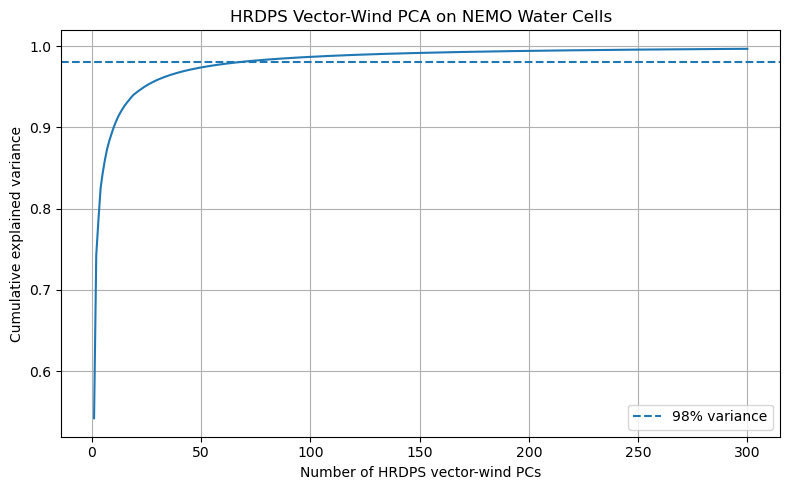

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1), hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold, linestyle="--", label="98% variance")
plt.xlabel("Number of HRDPS vector-wind PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS Vector-Wind PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:", hrdps_val_scores.shape)
print("HRDPS test scores:", hrdps_test_scores.shape)

HRDPS train scores: (26280, 67)
HRDPS val scores: (8744, 67)
HRDPS test scores: (8760, 67)


In [32]:
max_canrcm_pcs = min(100, X_canrcm_train.shape[0] - 1, X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs, svd_solver="randomized", random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

print("CanRCM PCA components:", pca_canrcm.components_.shape)
print("CanRCM train scores:", canrcm_train_scores_all.shape)
print("CanRCM val scores:", canrcm_val_scores_all.shape)
print("CanRCM test scores:", canrcm_test_scores_all.shape)

CanRCM PCA components: (100, 680)
CanRCM train scores: (26280, 100)
CanRCM val scores: (8744, 100)
CanRCM test scores: (8760, 100)


In [33]:
canrcm_pc_candidates = range(1, max_canrcm_pcs + 1)
val_r2_scores = []
for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:, :n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:, :n_canrcm_pcs_candidate]
    model = LinearRegression()
    model.fit(X_train_pc, hrdps_train_scores)
    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores, hrdps_val_scores_pred_candidate, multioutput="variance_weighted")
    val_r2_scores.append(val_r2)

val_r2_scores = np.array(val_r2_scores)
best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]
print("Best number of CanRCM PCs:", n_canrcm_pcs)

Best number of CanRCM PCs: 100


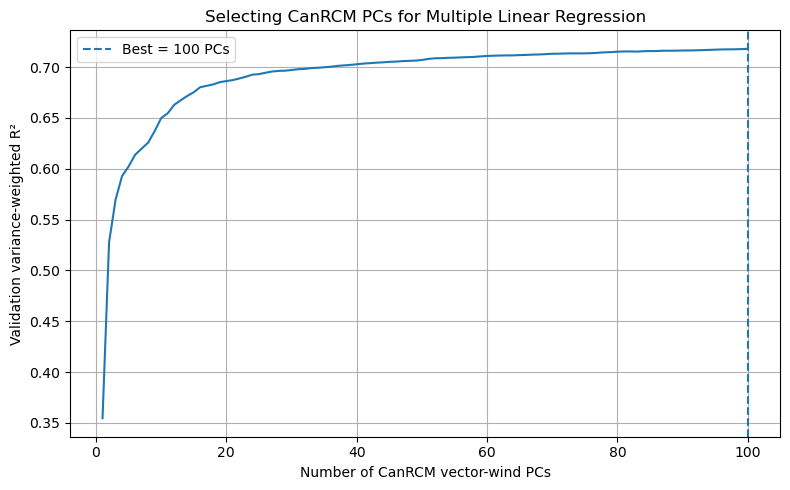

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates), val_r2_scores)
plt.axvline(n_canrcm_pcs, linestyle="--", label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM vector-wind PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
X_train_pc_final = canrcm_train_scores_all[:, :n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:, :n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:, :n_canrcm_pcs]

In [36]:
lr_model = LinearRegression()
lr_model.fit(X_train_pc_final, hrdps_train_scores)
hrdps_train_scores_pred = lr_model.predict(X_train_pc_final)
hrdps_val_scores_pred = lr_model.predict(X_val_pc_final)
hrdps_test_scores_pred = lr_model.predict(X_test_pc_final)
print("Regression coefficient shape:", lr_model.coef_.shape)
print("Predicted HRDPS train scores:", hrdps_train_scores_pred.shape)
print("Predicted HRDPS validation scores:", hrdps_val_scores_pred.shape)
print("Predicted HRDPS test scores:", hrdps_test_scores_pred.shape)

Regression coefficient shape: (67, 100)
Predicted HRDPS train scores: (26280, 67)
Predicted HRDPS validation scores: (8744, 67)
Predicted HRDPS test scores: (8760, 67)


In [37]:
def inverse_from_selected_hrdps_pcs(scores, pca, n_pcs):
    reconstructed = np.dot(scores, pca.components_[:n_pcs, :])
    reconstructed = reconstructed + pca.mean_
    return reconstructed.astype(np.float32)

In [38]:
X_hrdps_val_pred = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred, pca_hrdps, n_hrdps_pcs)
X_hrdps_test_pred = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred, pca_hrdps, n_hrdps_pcs)

In [39]:
# The first half is u_wind
# The second half is v_wind
X_hrdps_u_val_pred = X_hrdps_val_pred[:, :n_hrdps_cells]
X_hrdps_v_val_pred = X_hrdps_val_pred[:, n_hrdps_cells:]
X_hrdps_u_test_pred = X_hrdps_test_pred[:, :n_hrdps_cells]
X_hrdps_v_test_pred = X_hrdps_test_pred[:, n_hrdps_cells:]

In [40]:
def calculate_metrics(actual, predicted, label):
    rmse = np.sqrt(mean_squared_error(actual.ravel(),predicted.ravel()))
    mae = mean_absolute_error(actual.ravel(),predicted.ravel())
    bias = np.mean(predicted - actual)
    r2 = r2_score(actual,predicted,multioutput="variance_weighted")
    actual_std = np.std(actual, ddof=0)
    normalized_rmse = rmse / actual_std
    print(f"\n{label}")
    print("RMSE:", rmse)
    print("MAE: ", mae)
    print("Bias:", bias)
    print("R²:  ", r2)
    print("Actual standard deviation:", actual_std)
    print("Normalized RMSE:", normalized_rmse)
    print("Normalized RMSE (%):", normalized_rmse * 100)
    return {"RMSE": rmse,"MAE": mae,"Bias": bias,"R2": r2,"Normalized_RMSE": normalized_rmse,"Normalized_RMSE_percent": normalized_rmse * 100}

In [41]:
val_u_metrics = calculate_metrics(X_hrdps_u_val, X_hrdps_u_val_pred, "Validation U-wind metrics on NEMO water cells")
val_v_metrics = calculate_metrics(X_hrdps_v_val, X_hrdps_v_val_pred, "Validation V-wind metrics on NEMO water cells")
test_u_metrics = calculate_metrics(X_hrdps_u_test, X_hrdps_u_test_pred, "Test U-wind metrics on NEMO water cells")
test_v_metrics = calculate_metrics(X_hrdps_v_test, X_hrdps_v_test_pred, "Test V-wind metrics on NEMO water cells")


Validation U-wind metrics on NEMO water cells
RMSE: 2.110620992496878
MAE:  1.5414036512374878
Bias: -0.06638243
R²:   0.7130454182624817
Actual standard deviation: 4.0249295
Normalized RMSE: 0.5243870681935058
Normalized RMSE (%): 52.43870681935058

Validation V-wind metrics on NEMO water cells
RMSE: 1.7502690517138932
MAE:  1.2979990243911743
Bias: 0.112305805
R²:   0.6813398599624634
Actual standard deviation: 3.143629
Normalized RMSE: 0.5567670391319409
Normalized RMSE (%): 55.67670391319409

Test U-wind metrics on NEMO water cells
RMSE: 1.9341856387729683
MAE:  1.4131697416305542
Bias: 0.016652716
R²:   0.7332890033721924
Actual standard deviation: 3.790987
Normalized RMSE: 0.5102063476442841
Normalized RMSE (%): 51.02063476442841

Test V-wind metrics on NEMO water cells
RMSE: 1.6602525391423553
MAE:  1.218945026397705
Bias: -0.060556307
R²:   0.7221020460128784
Actual standard deviation: 3.1873794
Normalized RMSE: 0.5208832559669686
Normalized RMSE (%): 52.08832559669686


In [42]:
hrdps_speed_val = np.sqrt(X_hrdps_u_val**2 + X_hrdps_v_val**2)
hrdps_speed_val_pred = np.sqrt(X_hrdps_u_val_pred**2 + X_hrdps_v_val_pred**2)
hrdps_speed_test = np.sqrt(X_hrdps_u_test**2 + X_hrdps_v_test**2)
hrdps_speed_test_pred = np.sqrt(X_hrdps_u_test_pred**2 + X_hrdps_v_test_pred**2)
val_speed_metrics = calculate_metrics(hrdps_speed_val, hrdps_speed_val_pred, "Validation wind-speed metrics on NEMO water cells")
test_speed_metrics = calculate_metrics(hrdps_speed_test, hrdps_speed_test_pred, "Test wind-speed metrics on NEMO water cells")


Validation wind-speed metrics on NEMO water cells
RMSE: 2.0564274256259214
MAE:  1.5266567468643188
Bias: -0.78584373
R²:   0.44212573766708374
Actual standard deviation: 3.006005
Normalized RMSE: 0.6841064443587018
Normalized RMSE (%): 68.41064443587018

Test wind-speed metrics on NEMO water cells
RMSE: 1.9032819185255
MAE:  1.4124349355697632
Bias: -0.69047636
R²:   0.5162323117256165
Actual standard deviation: 2.8750415
Normalized RMSE: 0.6620015497397982
Normalized RMSE (%): 66.20015497397982


In [43]:
val_vector_rmse = np.sqrt(np.mean((X_hrdps_u_val_pred - X_hrdps_u_val)**2 + (X_hrdps_v_val_pred - X_hrdps_v_val)**2))
test_vector_rmse = np.sqrt(np.mean((X_hrdps_u_test_pred - X_hrdps_u_test)**2 + (X_hrdps_v_test_pred - X_hrdps_v_test)**2))
print("Validation vector RMSE:", val_vector_rmse, "m/s")
print("Test vector RMSE:", test_vector_rmse, "m/s")

Validation vector RMSE: 2.741927 m/s
Test vector RMSE: 2.5490217 m/s


In [44]:
def nemo_vector_to_map(vector):
    nemo_map = np.full(water_mask.shape, np.nan, dtype=np.float32)
    nemo_map[valid_nemo_j, valid_nemo_i] = vector
    return nemo_map

In [45]:
def plot_actual_predicted_error(time_index, X_actual, X_predicted, times, variable_label, unit="m/s"):
    actual_map = nemo_vector_to_map(X_actual[time_index])
    predicted_map = nemo_vector_to_map(X_predicted[time_index])
    error_map = predicted_map - actual_map
    value_min = np.nanmin(np.stack([actual_map, predicted_map]))
    value_max = np.nanmax(np.stack([actual_map, predicted_map]))
    error_limit = np.nanmax(np.abs(error_map))
    timestamp = pd.Timestamp(times[time_index])
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    p0 = axes[0].pcolormesh(actual_map, shading="auto", vmin=value_min, vmax=value_max)
    axes[0].set_title(f"Actual HRDPS on NEMO Grid\n{timestamp}")
    plt.colorbar(p0, ax=axes[0], label=f"{variable_label} ({unit})")
    p1 = axes[1].pcolormesh(predicted_map, shading="auto", vmin=value_min, vmax=value_max)
    axes[1].set_title(f"Predicted PCA + MLR\n{timestamp}")
    plt.colorbar(p1, ax=axes[1], label=f"{variable_label} ({unit})")
    p2 = axes[2].pcolormesh(error_map, shading="auto", cmap="RdBu_r", vmin=-error_limit, vmax=error_limit)
    axes[2].set_title(f"Predicted - Actual\n{timestamp}")
    plt.colorbar(p2, ax=axes[2], label=f"Error ({unit})")
    for ax in axes:
        ax.set_xlabel("NEMO x index (i)")
        ax.set_ylabel("NEMO y index (j)")
    fig.suptitle(variable_label, fontsize=15)
    plt.tight_layout()
    plt.show()

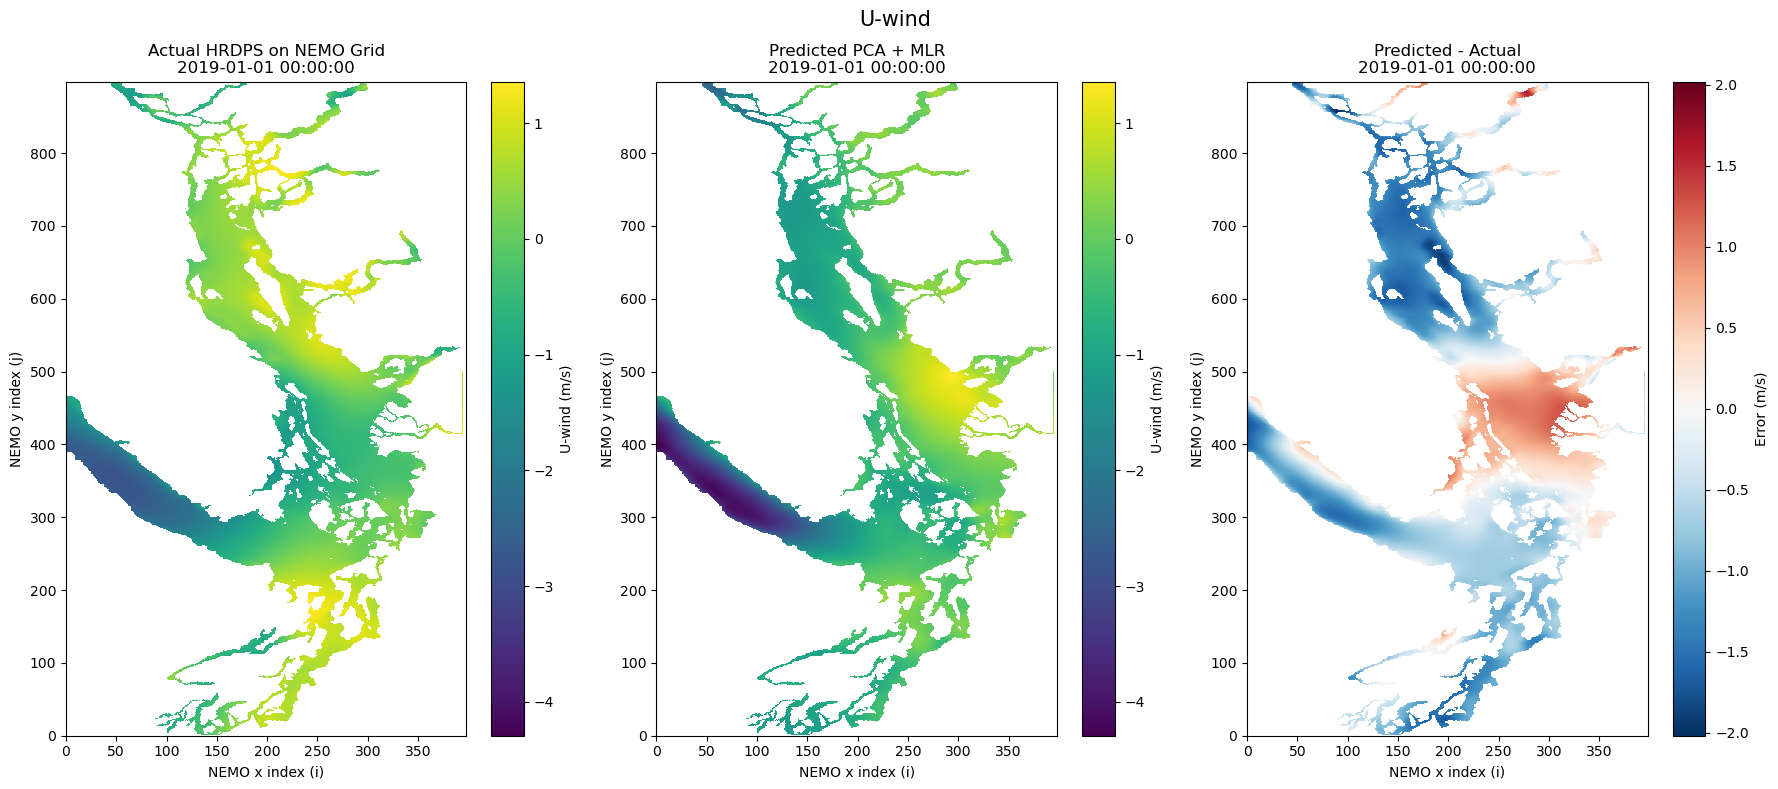

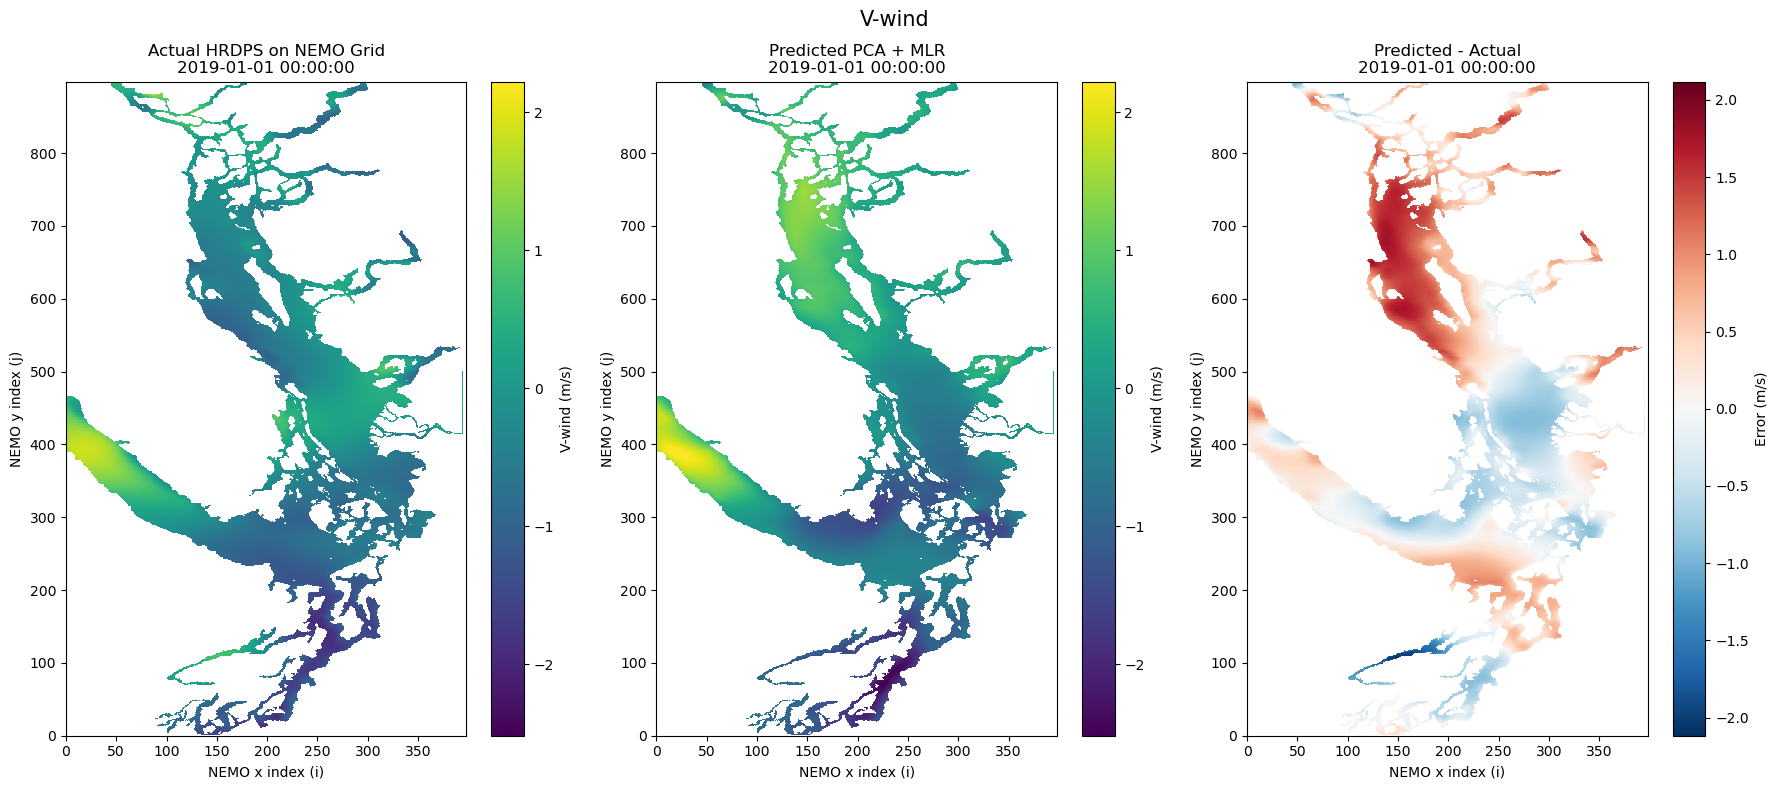

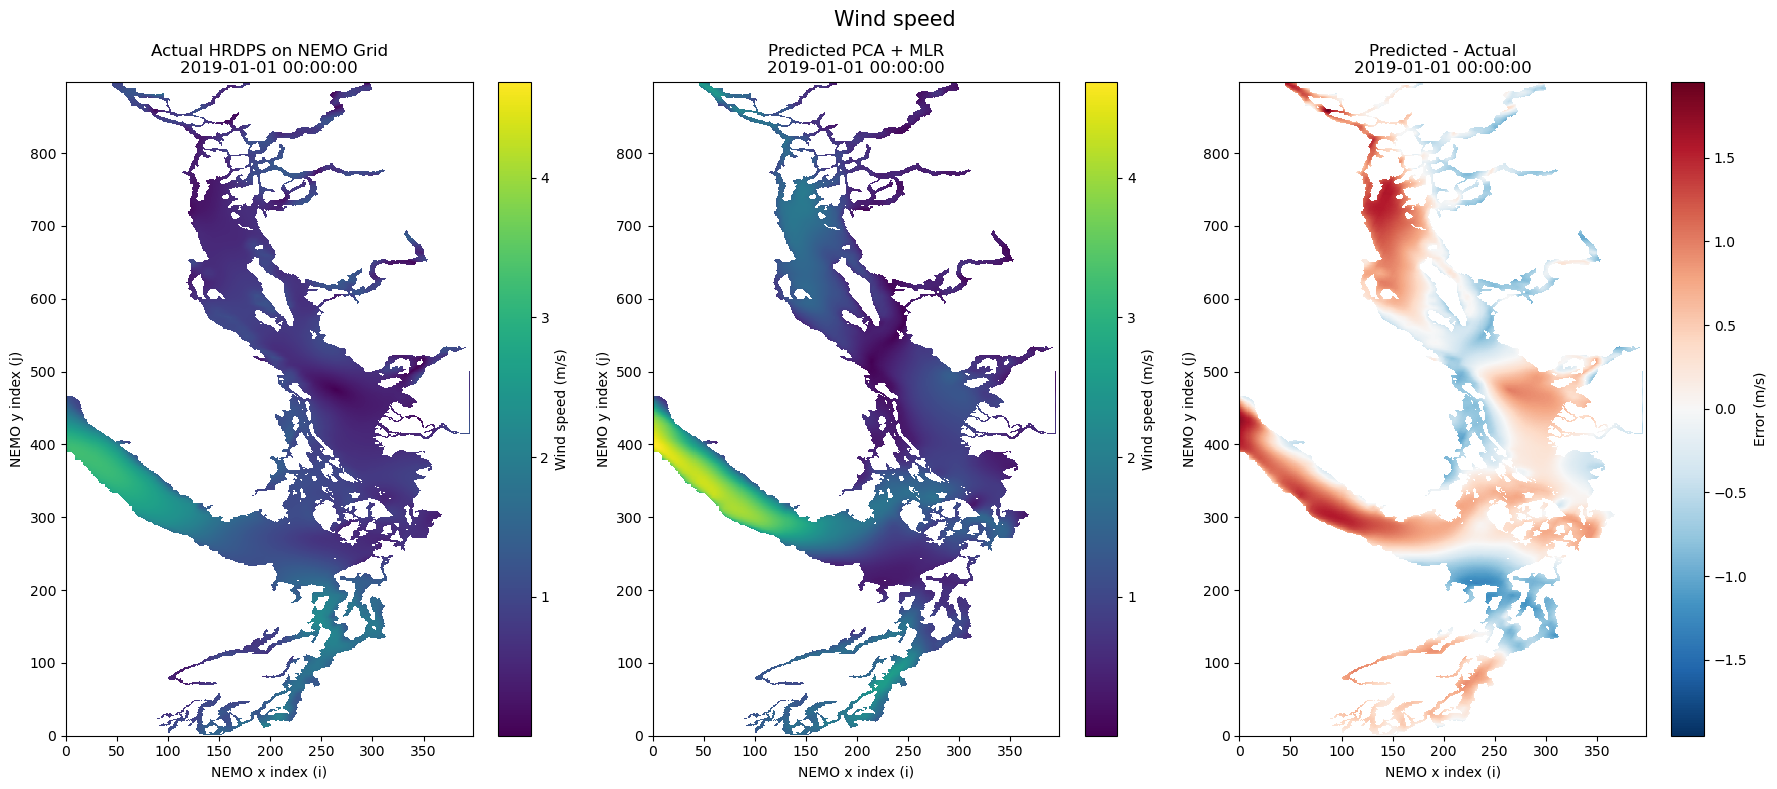

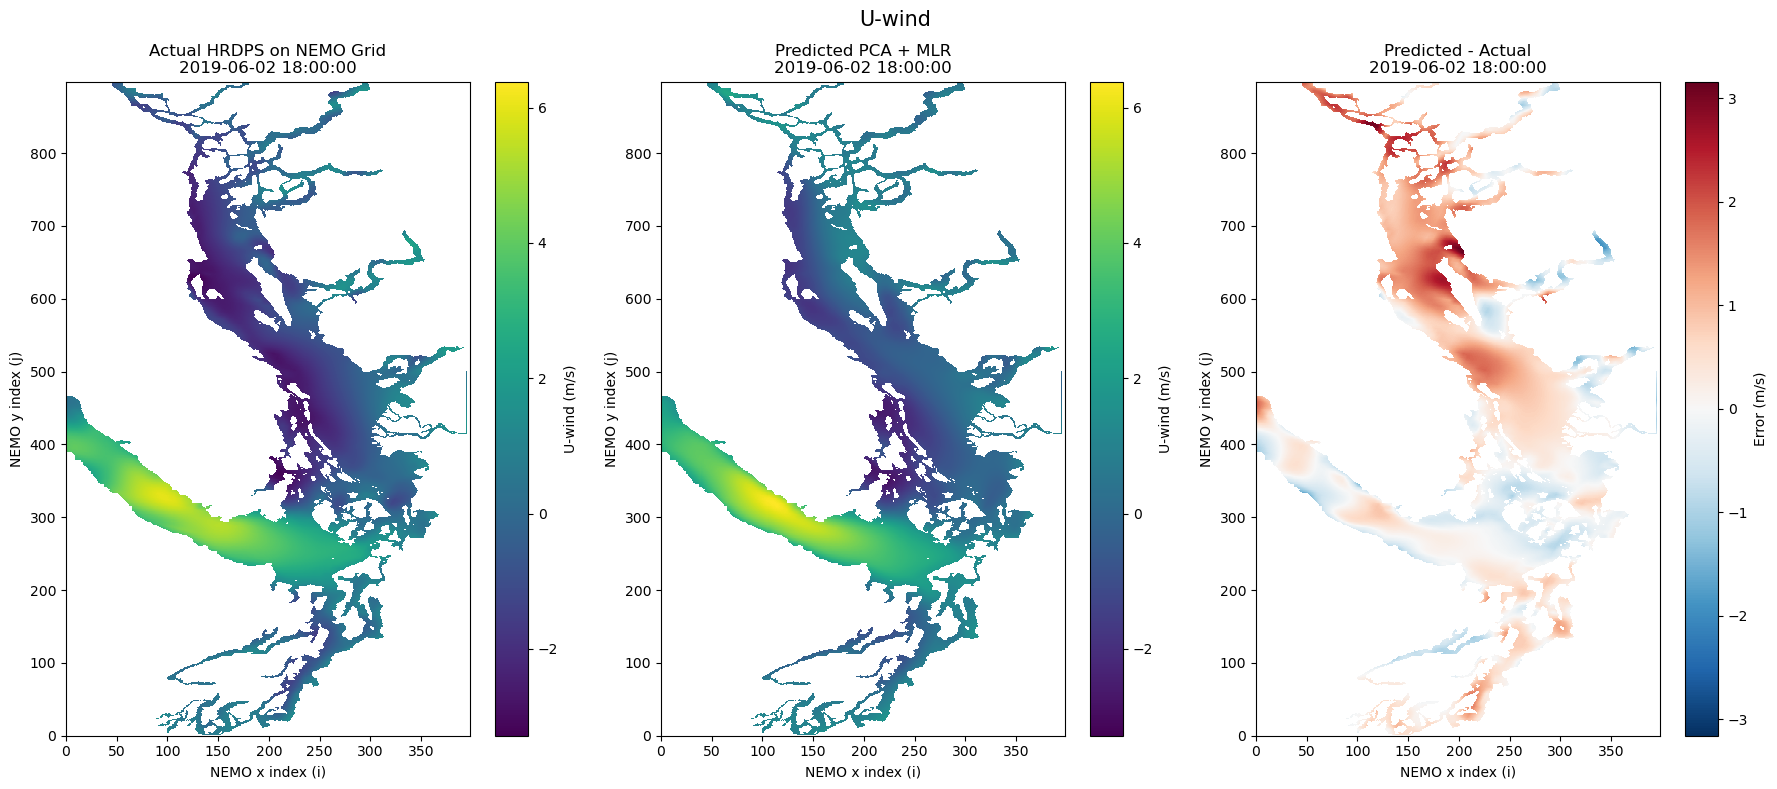

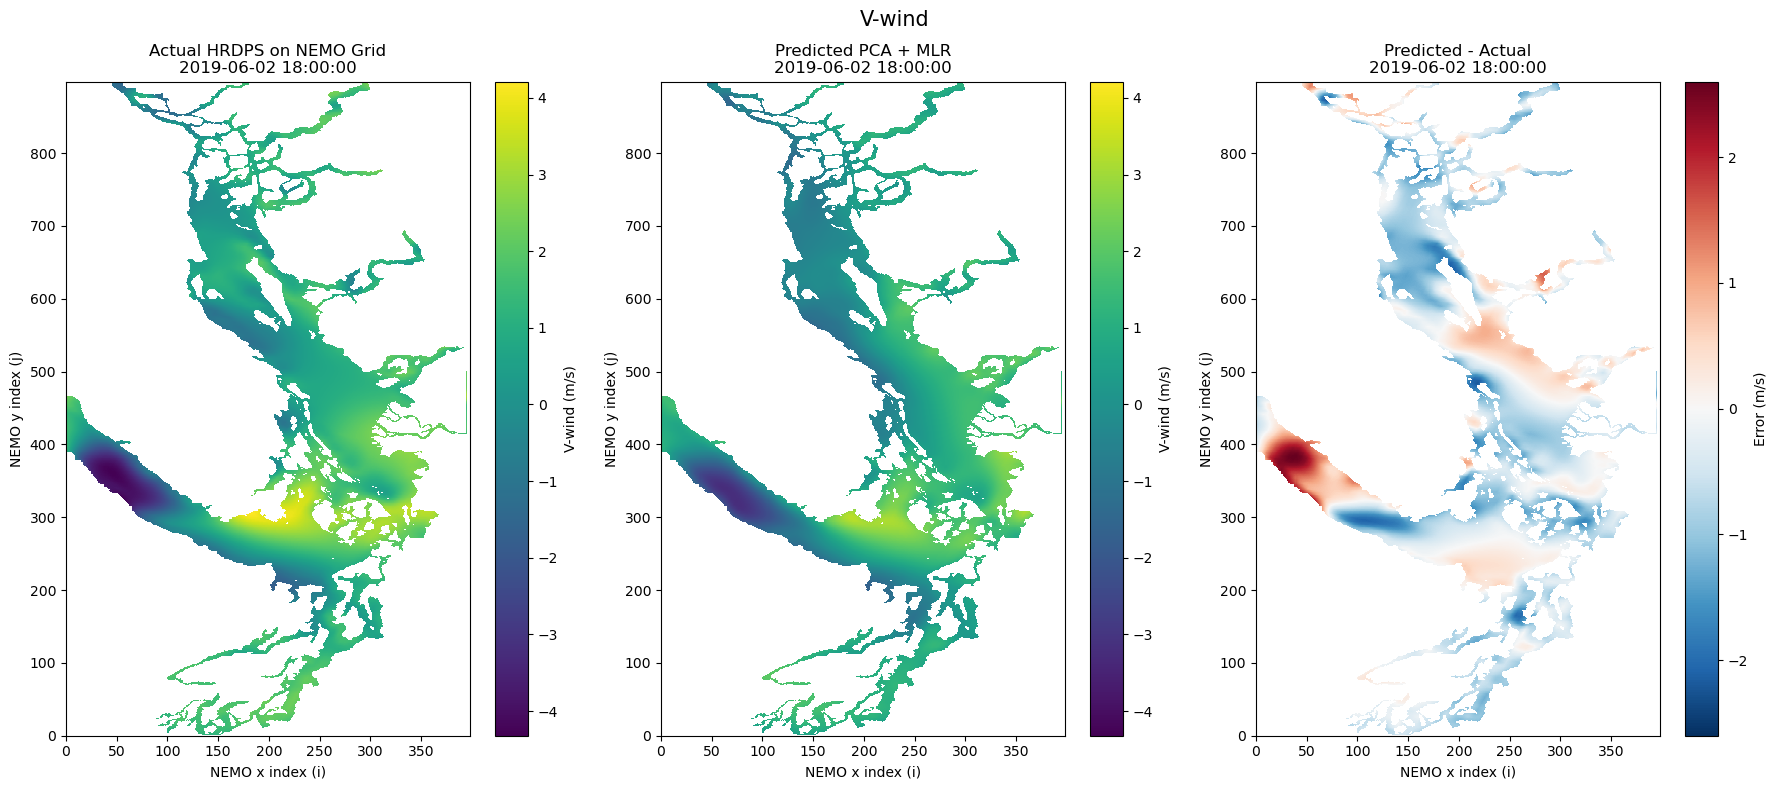

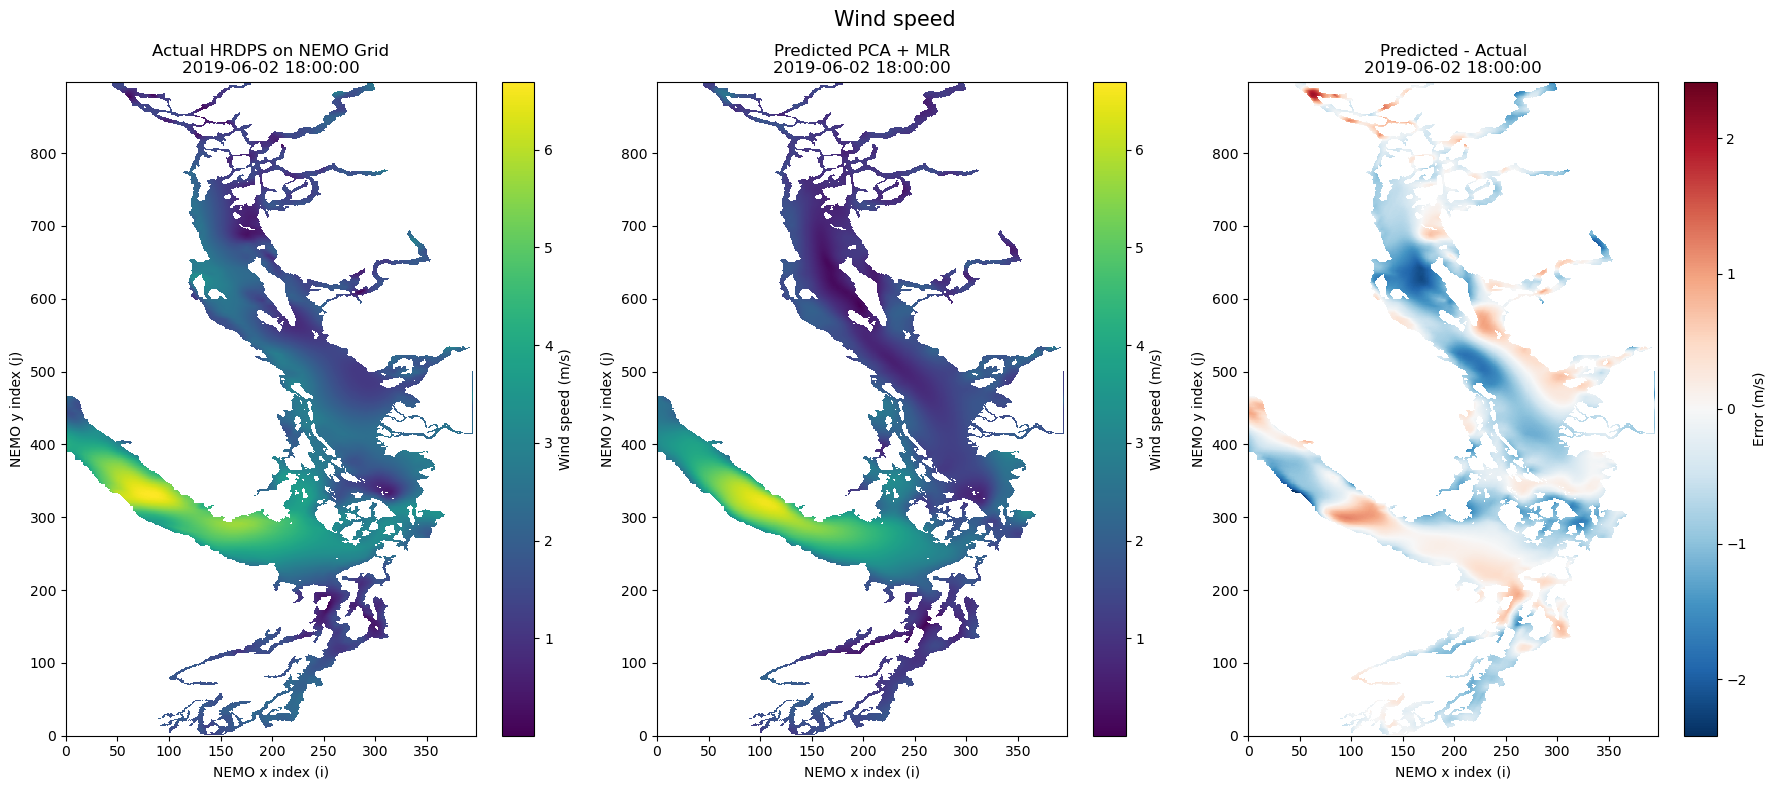

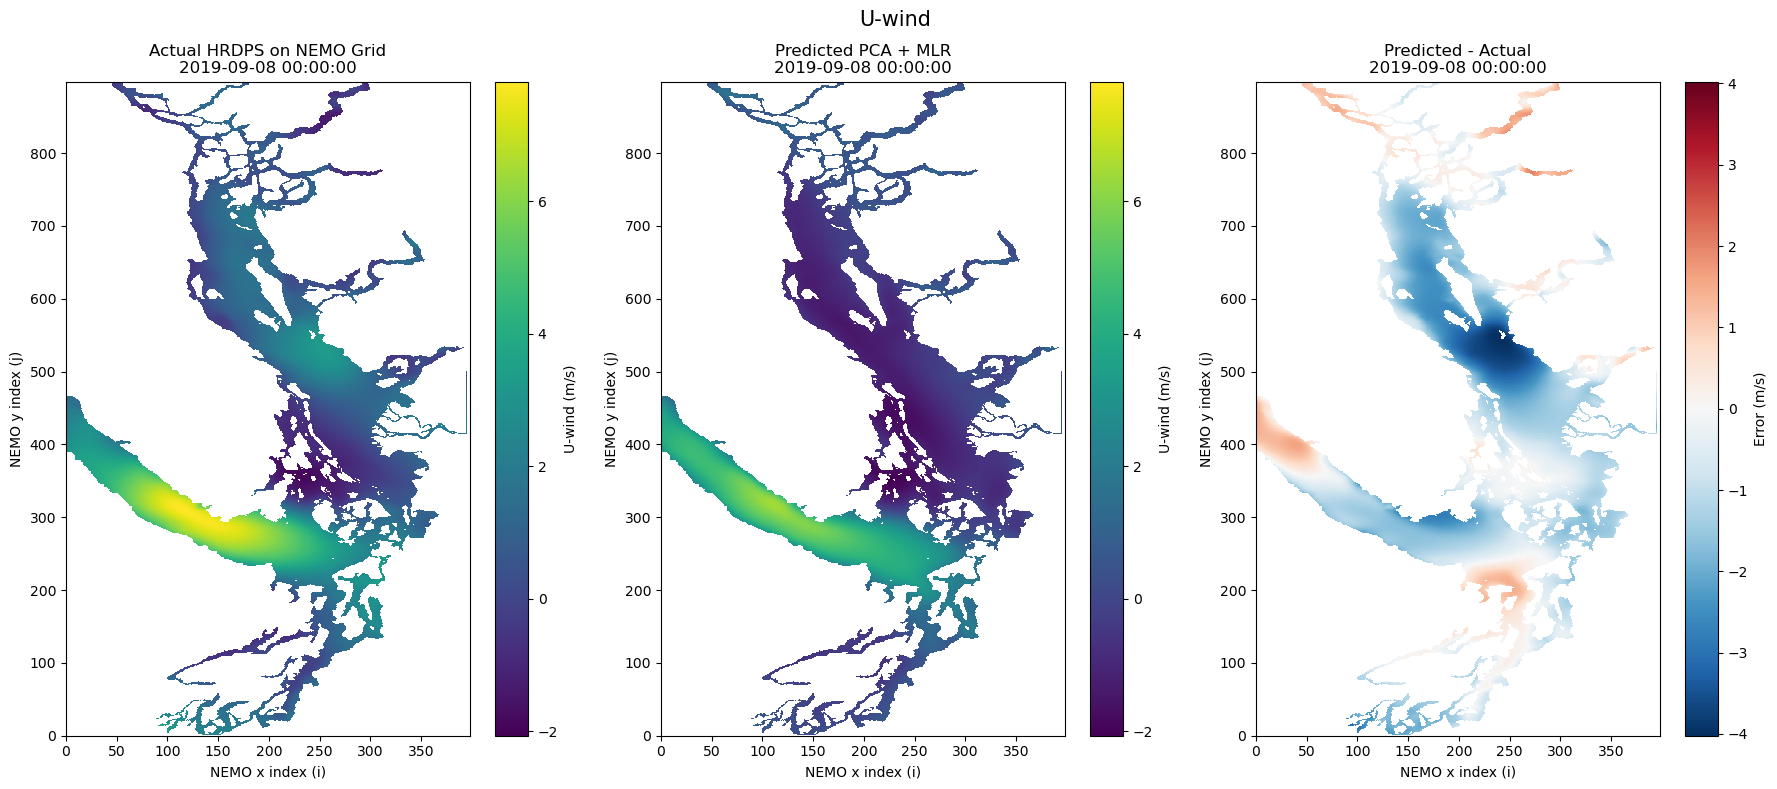

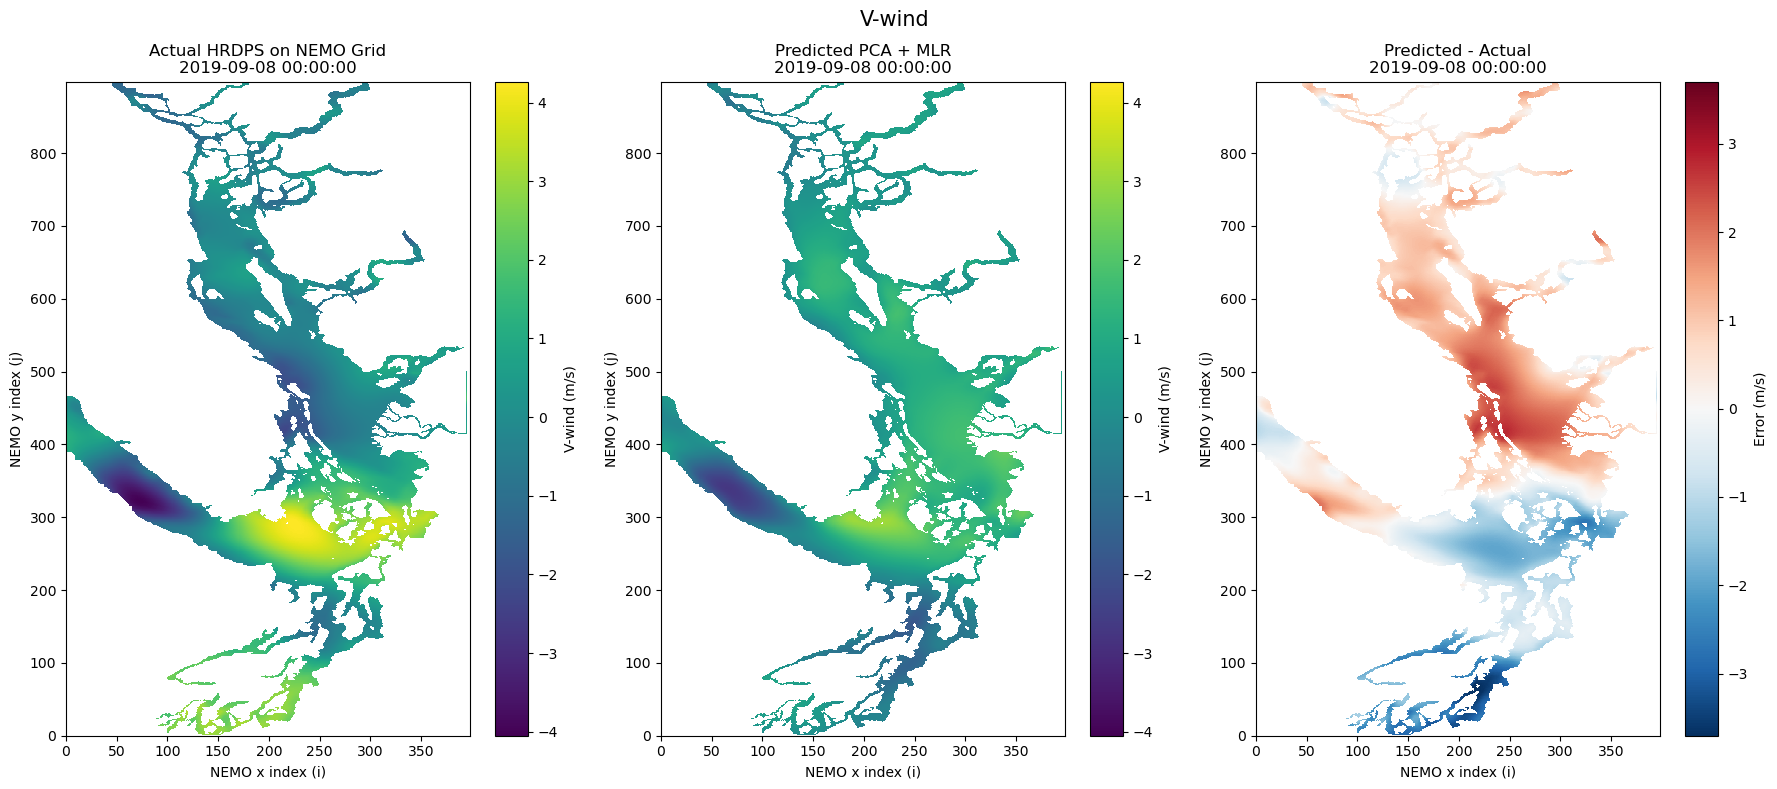

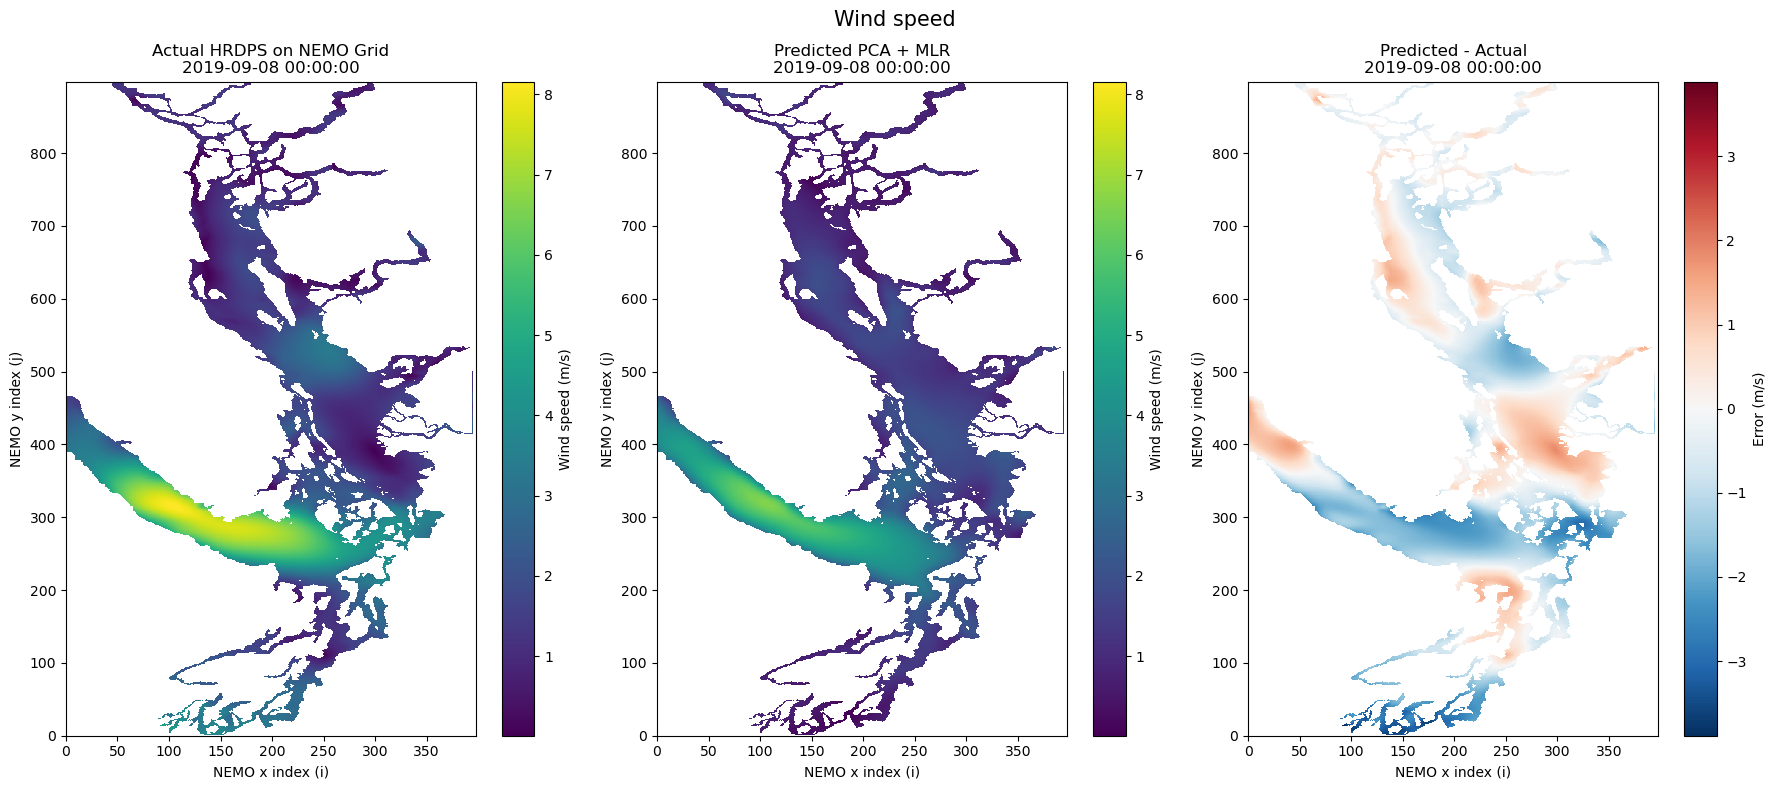

In [46]:
test_times = ds_hrdps_test["time_counter"].values
plot_time_indices = [0, 1222, 2000]
for time_index in plot_time_indices:
    plot_actual_predicted_error(time_index=time_index, X_actual=X_hrdps_u_test, X_predicted=X_hrdps_u_test_pred, times=test_times, variable_label="U-wind")
    plot_actual_predicted_error(time_index=time_index, X_actual=X_hrdps_v_test, X_predicted=X_hrdps_v_test_pred, times=test_times, variable_label="V-wind")
    plot_actual_predicted_error(time_index=time_index, X_actual=hrdps_speed_test, X_predicted=hrdps_speed_test_pred, times=test_times, variable_label="Wind speed")

In [47]:
def make_spatial_mean_timeseries(actual_matrix, predicted_matrix, times):
    actual_mean = np.mean(actual_matrix, axis=1)
    predicted_mean = np.mean(predicted_matrix, axis=1)
    timeseries = pd.DataFrame({"actual": actual_mean, "predicted": predicted_mean}, index=pd.to_datetime(times))
    timeseries.index.name = "Date"
    return timeseries

def plot_spatial_mean_timeseries(timeseries, start_date, end_date, variable_label, split_label, unit="m/s"):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(timeseries.index, timeseries["actual"], label="Actual HRDPS on NEMO grid", linewidth=1.2)
    ax.plot(timeseries.index, timeseries["predicted"], label="Predicted PCA + MLR", linewidth=1.2, alpha=0.7)
    ax.set_xlim(pd.Timestamp(start_date), pd.Timestamp(end_date))
    ax.set_xlabel("Date")
    ax.set_ylabel(f"Spatial mean {variable_label} ({unit})")
    ax.set_title(f"Actual vs Predicted {variable_label} - {split_label}")
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

In [48]:
val_times = ds_hrdps_val["time_counter"].values
test_times = ds_hrdps_test["time_counter"].values
u_timeseries_val = make_spatial_mean_timeseries(X_hrdps_u_val, X_hrdps_u_val_pred, val_times)
v_timeseries_val = make_spatial_mean_timeseries(X_hrdps_v_val, X_hrdps_v_val_pred, val_times)
speed_timeseries_val = make_spatial_mean_timeseries(hrdps_speed_val, hrdps_speed_val_pred, val_times)
u_timeseries_test = make_spatial_mean_timeseries(X_hrdps_u_test, X_hrdps_u_test_pred, test_times)
v_timeseries_test = make_spatial_mean_timeseries(X_hrdps_v_test, X_hrdps_v_test_pred, test_times)
speed_timeseries_test = make_spatial_mean_timeseries(hrdps_speed_test, hrdps_speed_test_pred, test_times)

print(u_timeseries_val.head())
print(v_timeseries_val.head())
print(speed_timeseries_val.head())
print(u_timeseries_test.head())
print(v_timeseries_test.head())
print(speed_timeseries_test.head())

                       actual  predicted
Date                                    
2007-01-03 00:00:00  4.018008   2.787014
2007-01-03 03:00:00  2.101623   3.013752
2007-01-03 06:00:00  2.288602   1.713364
2007-01-03 09:00:00  1.296123  -0.431772
2007-01-03 12:00:00 -0.637353  -1.279993
                       actual  predicted
Date                                    
2007-01-03 00:00:00  3.402031   4.219910
2007-01-03 03:00:00  2.990175   3.061124
2007-01-03 06:00:00  2.813164   2.795658
2007-01-03 09:00:00  3.636829   2.982060
2007-01-03 12:00:00  3.110152   3.265545
                       actual  predicted
Date                                    
2007-01-03 00:00:00  5.614164   5.848918
2007-01-03 03:00:00  4.294266   4.928454
2007-01-03 06:00:00  4.454810   3.962747
2007-01-03 09:00:00  4.484822   3.501317
2007-01-03 12:00:00  4.047542   3.741545
                       actual  predicted
Date                                    
2019-01-01 00:00:00 -0.173595  -0.659657
2019-01-01 03:00

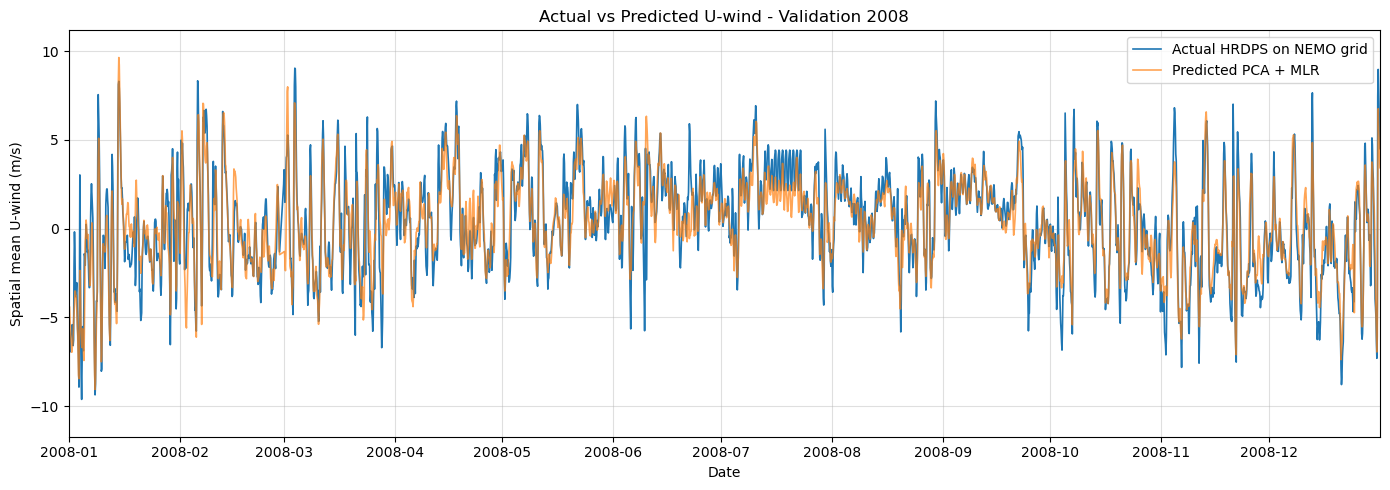

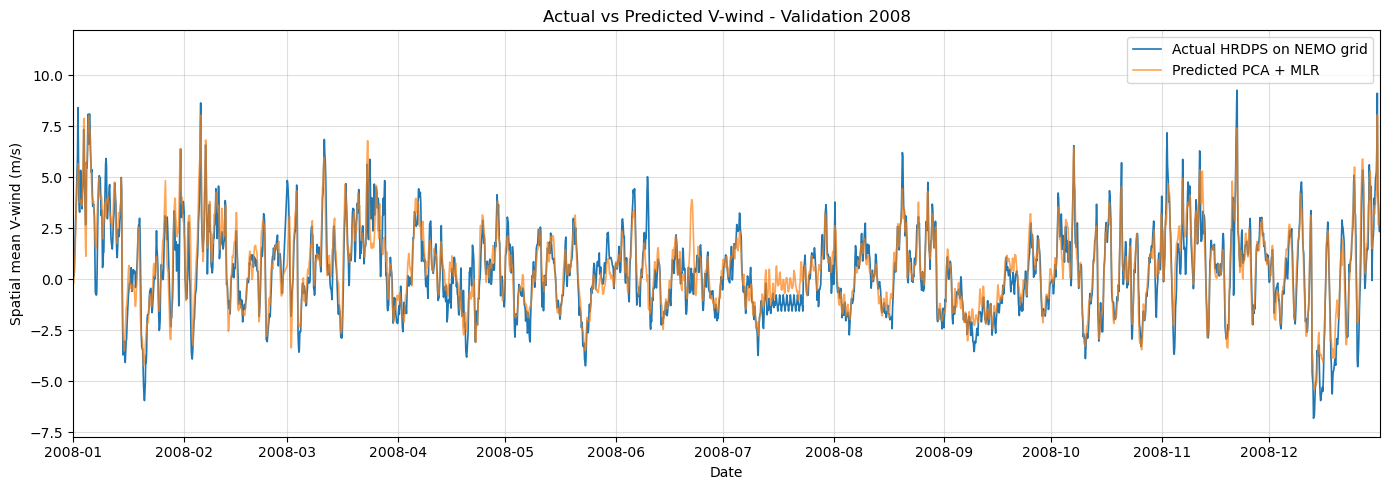

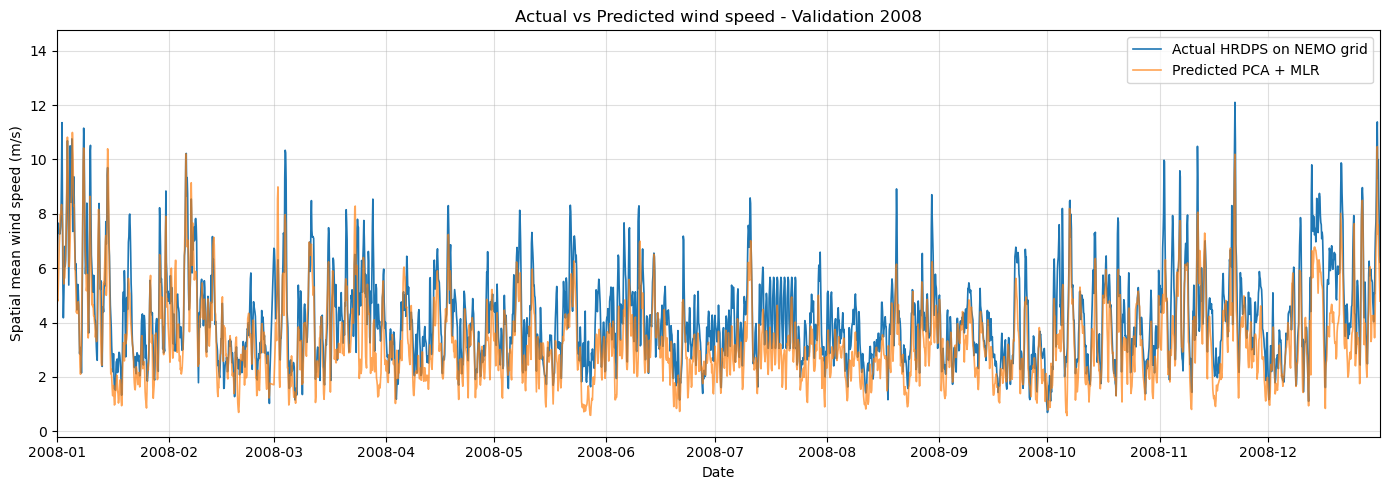

In [49]:
for timeseries, variable_label in [(u_timeseries_val, "U-wind"), (v_timeseries_val, "V-wind"), (speed_timeseries_val, "wind speed")]:
    plot_spatial_mean_timeseries(timeseries=timeseries,
                                  start_date="2008-01-01",
                                    end_date="2008-12-31 23:59:59", variable_label=variable_label, split_label="Validation 2008")

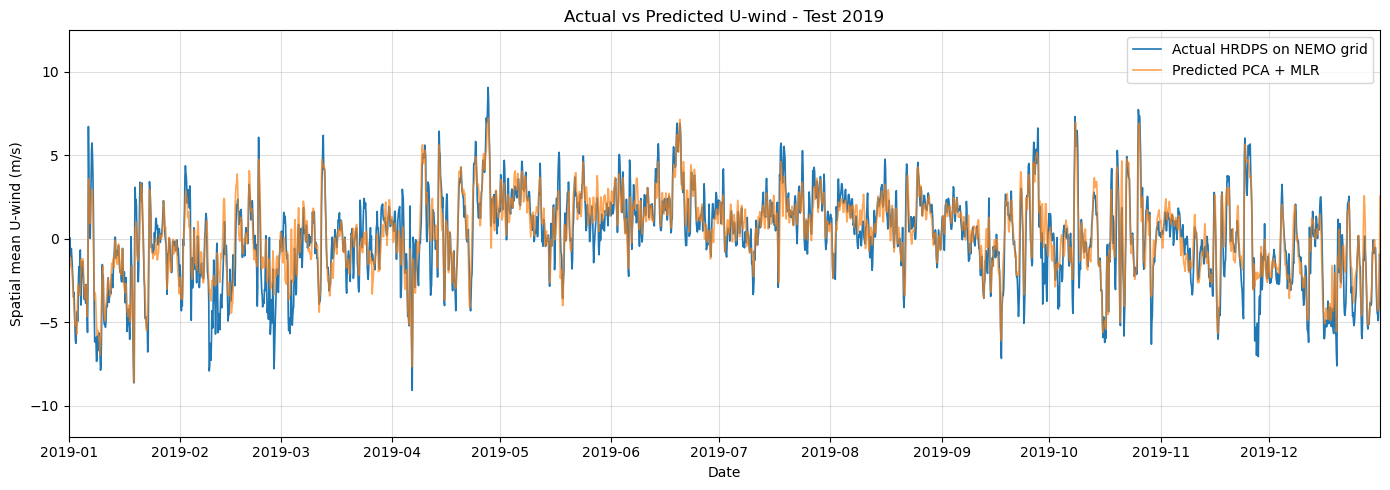

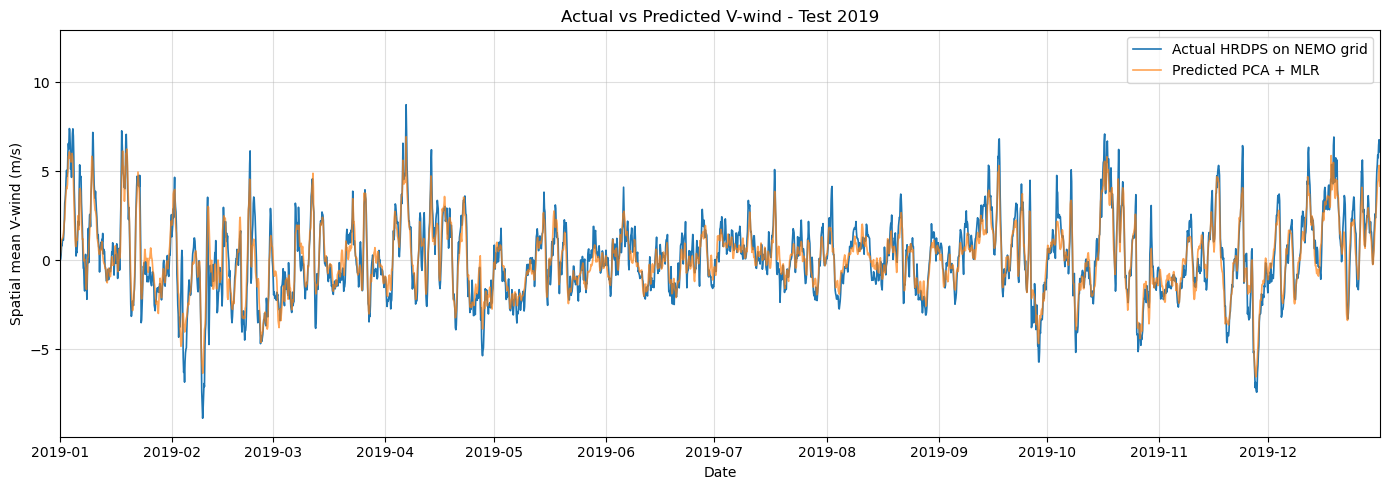

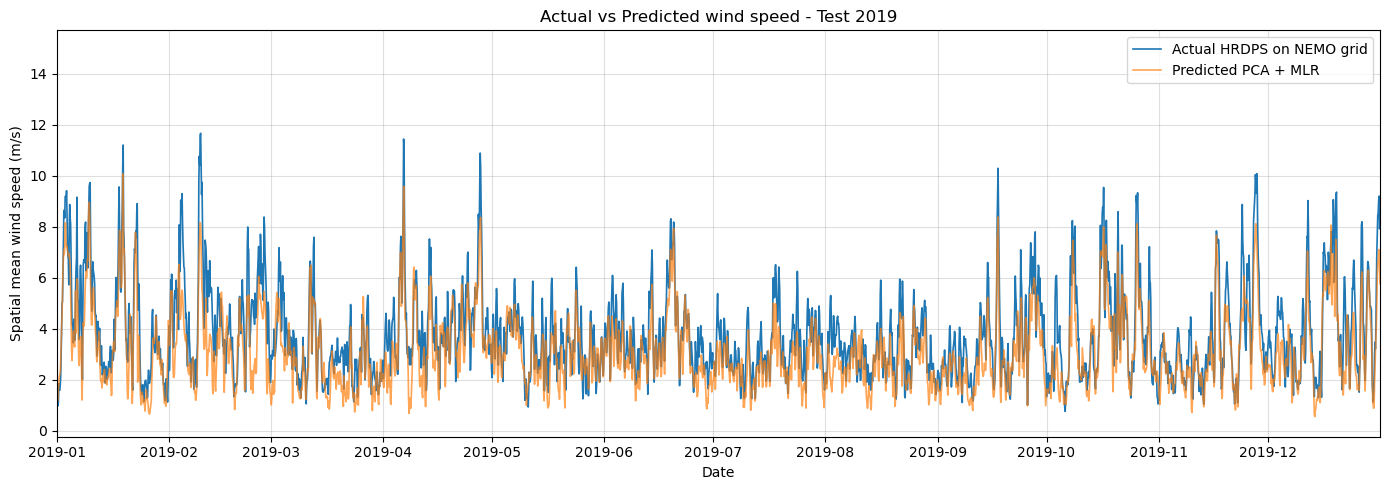

In [50]:
for timeseries, variable_label in [(u_timeseries_test, "U-wind"), (v_timeseries_test, "V-wind"), (speed_timeseries_test, "wind speed")]:
    plot_spatial_mean_timeseries(timeseries=timeseries, 
                                 start_date="2019-01-01", 
                                 end_date="2019-12-31 23:59:59", variable_label=variable_label, split_label="Test 2019")

In [51]:
stations = {
    "Sand Heads": {"j": 426, "i": 293},
    "Halibut Bank": {"j": 503, "i": 261},
    "Sentry Shoal": {"j": 707, "i": 145},
}

In [52]:
def find_station_column(station_j, station_i):
    matches = np.where((valid_nemo_j == station_j) & (valid_nemo_i == station_i))[0]
    if len(matches) == 0:
        raise ValueError(f"Station cell j={station_j}, i={station_i} was not retained in valid_nemo_cols.")
    return int(matches[0])
for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"], station_info["i"])
    stations[station_name]["column"] = column
    print(station_name, "j =", station_info["j"], "i =", station_info["i"], "matrix column =", column)

Sand Heads j = 426 i = 293 matrix column = 44165
Halibut Bank j = 503 i = 261 matrix column = 53329
Sentry Shoal j = 707 i = 145 matrix column = 71870


In [53]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)
station_timeseries = {}
station_metrics = []
for station_name, station_info in stations.items():
    column = station_info["column"]
    actual_u = X_hrdps_u_test[:, column]
    predicted_u = X_hrdps_u_test_pred[:, column]
    actual_v = X_hrdps_v_test[:, column]
    predicted_v = X_hrdps_v_test_pred[:, column]
    actual_speed = np.sqrt(actual_u**2 + actual_v**2)
    predicted_speed = np.sqrt(predicted_u**2 + predicted_v**2)
    station_df = pd.DataFrame({"actual_u": actual_u, "predicted_u": predicted_u, "actual_v": actual_v, "predicted_v": predicted_v, "actual_speed": actual_speed, "predicted_speed": predicted_speed}, index=test_times)
    station_df.index.name = "Date"
    rmse_u = np.sqrt(mean_squared_error(actual_u, predicted_u))
    rmse_v = np.sqrt(mean_squared_error(actual_v, predicted_v))
    rmse_speed = np.sqrt(mean_squared_error(actual_speed, predicted_speed))
    vector_rmse = np.sqrt(np.mean((predicted_u - actual_u)**2 + (predicted_v - actual_v)**2))
    station_timeseries[station_name] = station_df
    station_metrics.append({"Station": station_name, "RMSE_u_mps": rmse_u, "RMSE_v_mps": rmse_v, "RMSE_speed_mps": rmse_speed, "Vector_RMSE_mps": vector_rmse})
station_rmse_table = pd.DataFrame(station_metrics)
print(station_rmse_table.to_string(index=False))

     Station  RMSE_u_mps  RMSE_v_mps  RMSE_speed_mps  Vector_RMSE_mps
  Sand Heads    2.363742    1.884071        2.171905         3.022748
Halibut Bank    2.651671    1.682278        2.359514         3.140290
Sentry Shoal    1.923332    1.946615        2.137091         2.736516


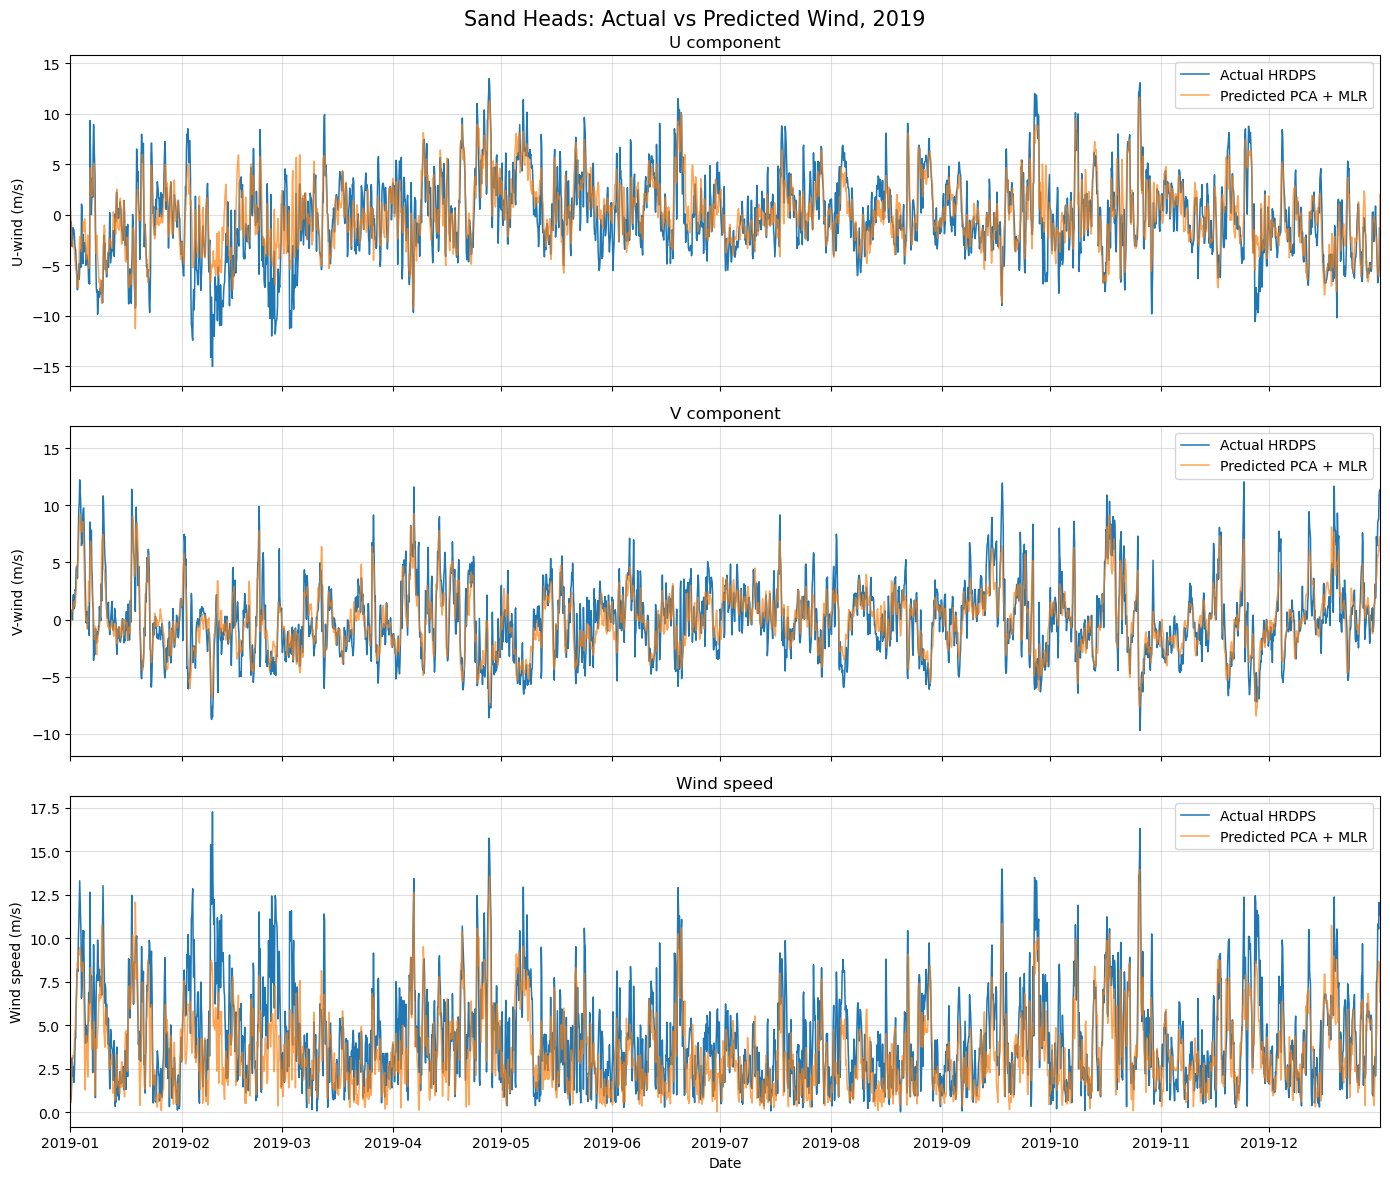

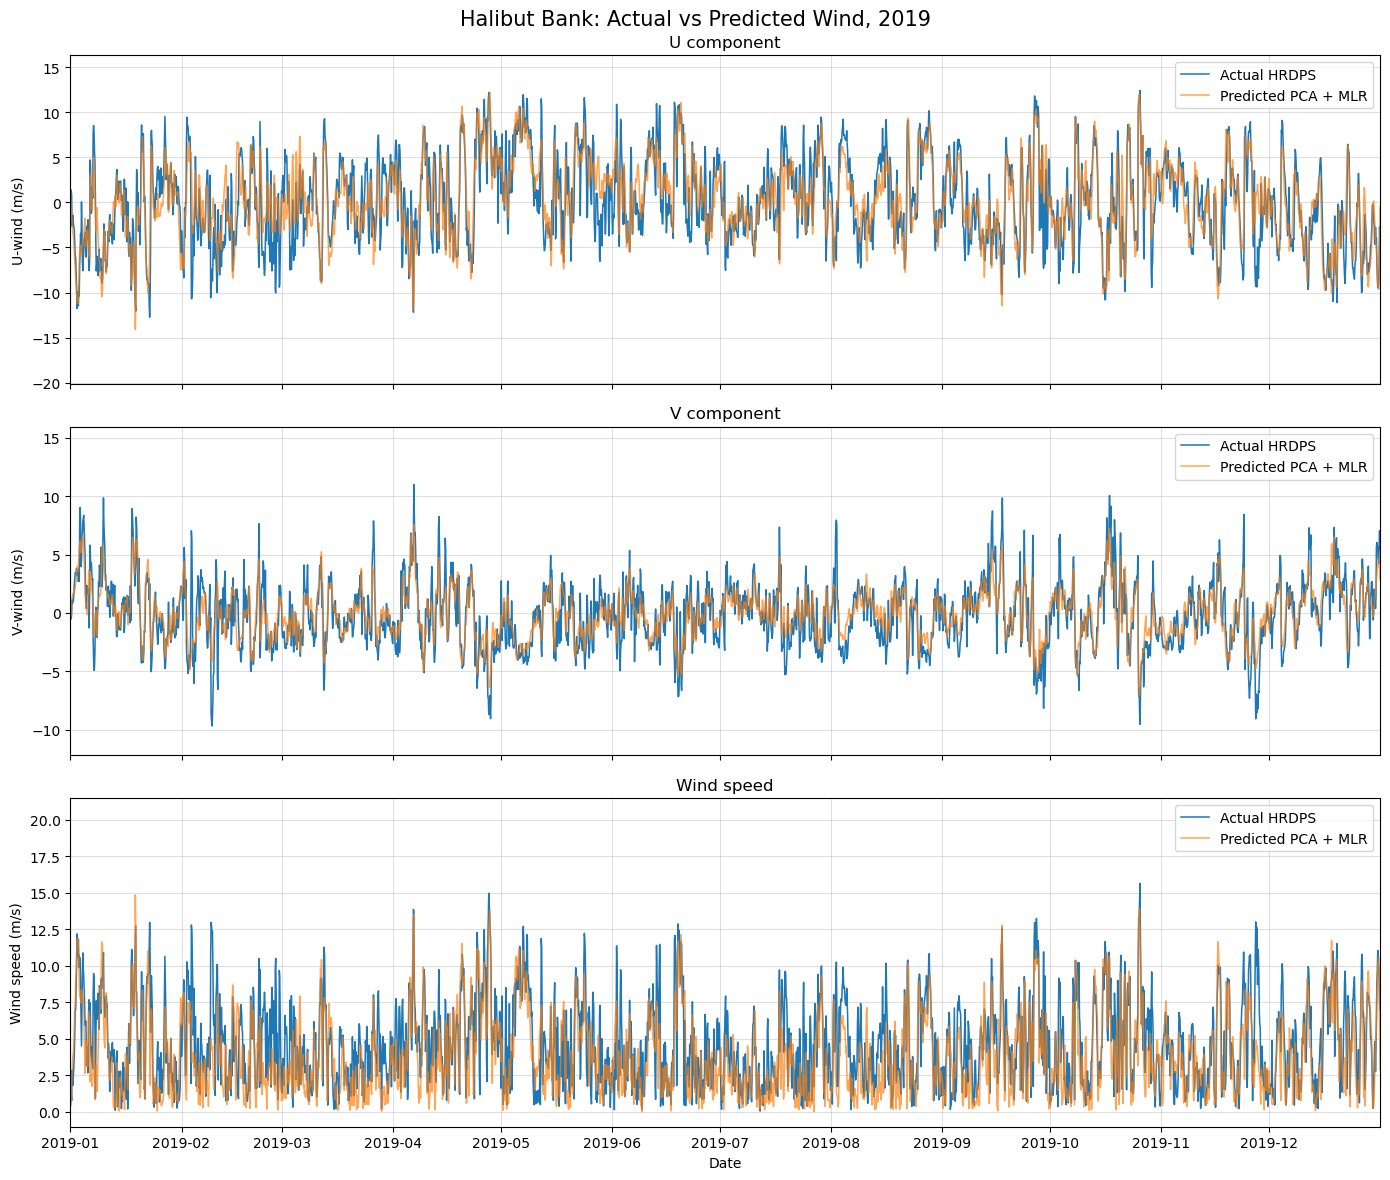

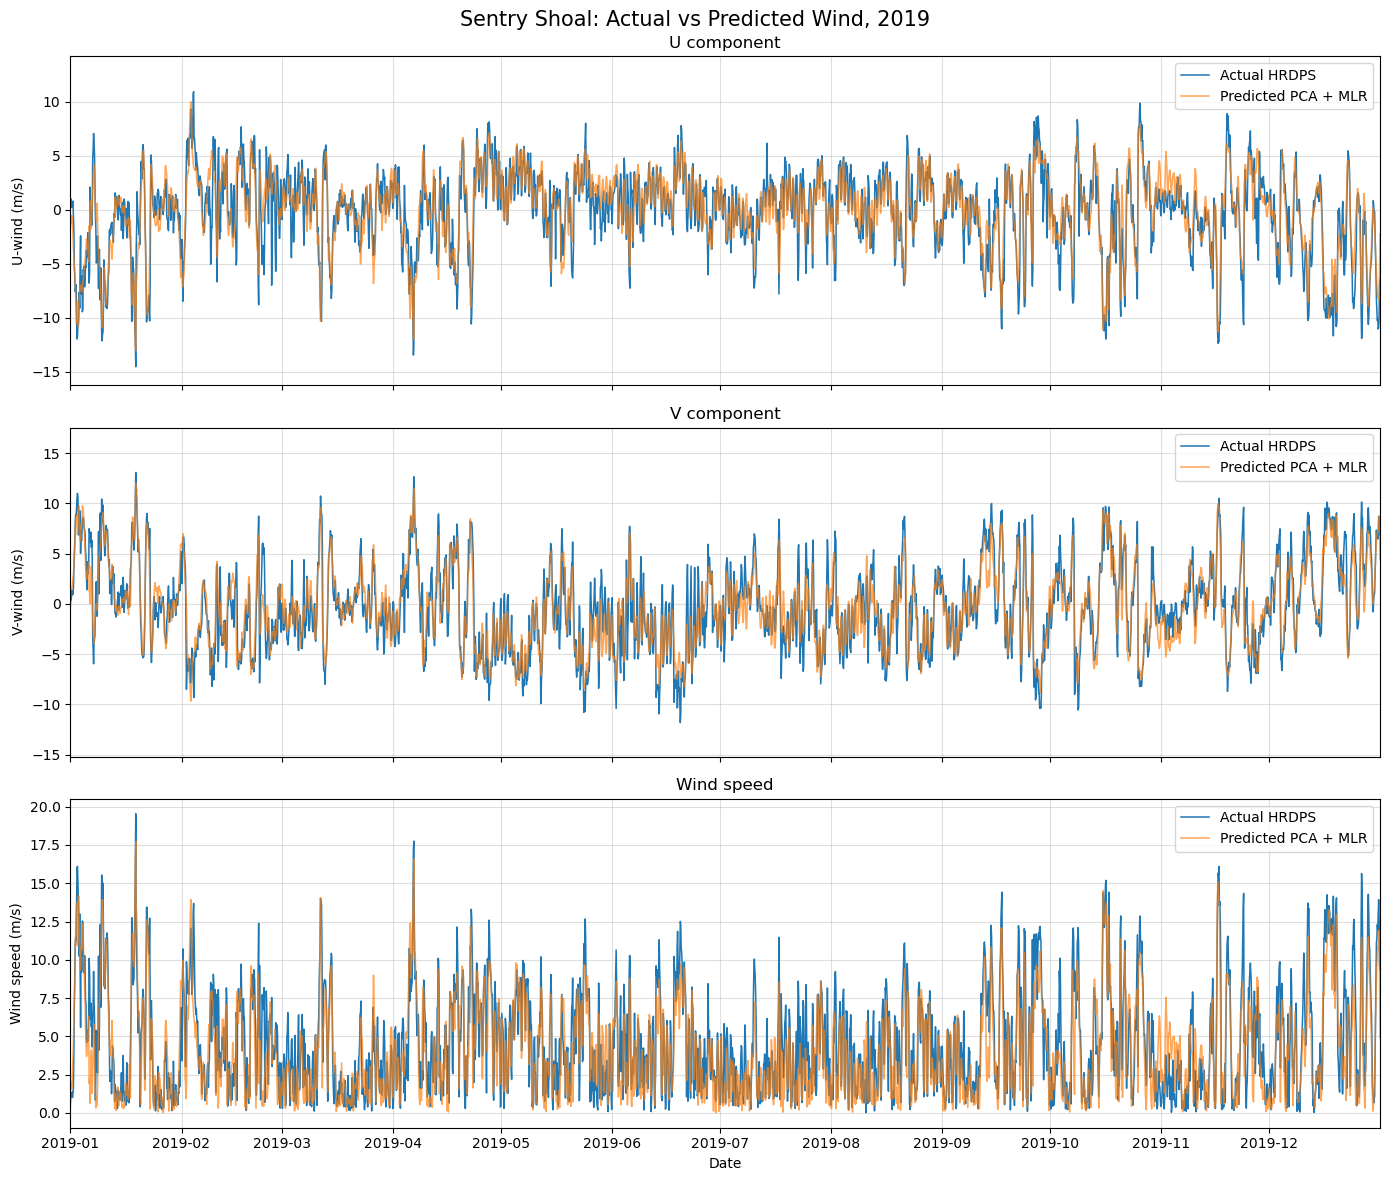

In [54]:
for station_name, station_df in station_timeseries.items():
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    axes[0].plot(station_df.index, station_df["actual_u"], label="Actual HRDPS", linewidth=1.1)
    axes[0].plot(station_df.index, station_df["predicted_u"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    axes[0].set_ylabel("U-wind (m/s)")   
    axes[0].set_title("U component")
    axes[0].legend()
    axes[0].grid(True, alpha=0.4)
    axes[1].plot(station_df.index, station_df["actual_v"], label="Actual HRDPS", linewidth=1.1)
    axes[1].plot(station_df.index, station_df["predicted_v"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    axes[1].set_ylabel("V-wind (m/s)")
    axes[1].set_title("V component")
    axes[1].legend()
    axes[1].grid(True, alpha=0.4)
    axes[2].plot(station_df.index, station_df["actual_speed"], label="Actual HRDPS", linewidth=1.1)
    axes[2].plot(station_df.index, station_df["predicted_speed"], label="Predicted PCA + MLR", linewidth=1.1, alpha=0.7)
    axes[2].set_ylabel("Wind speed (m/s)")
    axes[2].set_xlabel("Date")
    axes[2].set_title("Wind speed")
    axes[2].legend()
    axes[2].grid(True, alpha=0.4)
    axes[2].set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
    fig.suptitle(f"{station_name}: Actual vs Predicted Wind, 2019", fontsize=15)
    plt.tight_layout()
    plt.show()

In [55]:
average_station_metrics = station_rmse_table[["RMSE_u_mps", "RMSE_v_mps", "RMSE_speed_mps", "Vector_RMSE_mps"]].mean()
print("Average station metrics:")
print(average_station_metrics)

Average station metrics:
RMSE_u_mps         2.312915
RMSE_v_mps         1.837655
RMSE_speed_mps     2.222837
Vector_RMSE_mps    2.966518
dtype: float64


In [56]:
metrics_output_dir = "/ocean/dtaneja/MOAD/analysis-dishika/notebooks/All_years_Set1/PCA_LR"
os.makedirs(metrics_output_dir, exist_ok=True)
summary_metrics = pd.DataFrame([
    {"split": "validation", "variable": "u", **val_u_metrics},
    {"split": "validation", "variable": "v", **val_v_metrics},
    {"split": "validation", "variable": "speed", **val_speed_metrics},
    {"split": "test", "variable": "u", **test_u_metrics},
    {"split": "test", "variable": "v", **test_v_metrics},
    {"split": "test", "variable": "speed", **test_speed_metrics},
])
summary_metrics["selected_hrdps_pcs"] = n_hrdps_pcs
summary_metrics["selected_canrcm_pcs"] = n_canrcm_pcs
summary_metrics.to_csv(f"{metrics_output_dir}/wind_summary_metrics.csv", index=False)
station_rmse_table.to_csv(f"{metrics_output_dir}/wind_station_metrics.csv", index=False)
print(summary_metrics)
print("Saved metrics to:", metrics_output_dir)

        split variable      RMSE       MAE      Bias        R2  \
0  validation        u  2.110621  1.541404 -0.066382  0.713045   
1  validation        v  1.750269  1.297999  0.112306  0.681340   
2  validation    speed  2.056427  1.526657 -0.785844  0.442126   
3        test        u  1.934186  1.413170  0.016653  0.733289   
4        test        v  1.660253  1.218945 -0.060556  0.722102   
5        test    speed  1.903282  1.412435 -0.690476  0.516232   

   Normalized_RMSE  Normalized_RMSE_percent  selected_hrdps_pcs  \
0         0.524387                52.438707                  67   
1         0.556767                55.676704                  67   
2         0.684106                68.410644                  67   
3         0.510206                51.020635                  67   
4         0.520883                52.088326                  67   
5         0.662002                66.200155                  67   

   selected_canrcm_pcs  
0                  100  
1                

In [57]:
X_hrdps_train_pred = inverse_from_selected_hrdps_pcs(
    hrdps_train_scores_pred,
    pca_hrdps,
    n_hrdps_pcs
)

X_hrdps_val_pred = inverse_from_selected_hrdps_pcs(
    hrdps_val_scores_pred,
    pca_hrdps,
    n_hrdps_pcs
)

X_hrdps_test_pred = inverse_from_selected_hrdps_pcs(
    hrdps_test_scores_pred,
    pca_hrdps,
    n_hrdps_pcs
)

print("Actual training matrix:", X_hrdps_train.shape)
print("Predicted training matrix:", X_hrdps_train_pred.shape)

print("Actual validation matrix:", X_hrdps_val.shape)
print("Predicted validation matrix:", X_hrdps_val_pred.shape)

print("Actual test matrix:", X_hrdps_test.shape)
print("Predicted test matrix:", X_hrdps_test_pred.shape)

Actual training matrix: (26280, 162766)
Predicted training matrix: (26280, 162766)
Actual validation matrix: (8744, 162766)
Predicted validation matrix: (8744, 162766)
Actual test matrix: (8760, 162766)
Predicted test matrix: (8760, 162766)


In [58]:
# The first half is u_wind.
# The second half is v_wind.

X_hrdps_u_train_pred = X_hrdps_train_pred[:, :n_hrdps_cells]
X_hrdps_v_train_pred = X_hrdps_train_pred[:, n_hrdps_cells:]

X_hrdps_u_val_pred = X_hrdps_val_pred[:, :n_hrdps_cells]
X_hrdps_v_val_pred = X_hrdps_val_pred[:, n_hrdps_cells:]

X_hrdps_u_test_pred = X_hrdps_test_pred[:, :n_hrdps_cells]
X_hrdps_v_test_pred = X_hrdps_test_pred[:, n_hrdps_cells:]

print("Predicted training U:", X_hrdps_u_train_pred.shape)
print("Predicted training V:", X_hrdps_v_train_pred.shape)

print("Predicted validation U:", X_hrdps_u_val_pred.shape)
print("Predicted validation V:", X_hrdps_v_val_pred.shape)

print("Predicted test U:", X_hrdps_u_test_pred.shape)
print("Predicted test V:", X_hrdps_v_test_pred.shape)

Predicted training U: (26280, 81383)
Predicted training V: (26280, 81383)
Predicted validation U: (8744, 81383)
Predicted validation V: (8744, 81383)
Predicted test U: (8760, 81383)
Predicted test V: (8760, 81383)


In [59]:
true_training_energy = np.mean(X_hrdps_u_train**2 + X_hrdps_v_train**2)
pred_training_energy = np.mean(X_hrdps_u_train_pred**2 + X_hrdps_v_train_pred**2)

energy_scaling_constant = np.sqrt(true_training_energy / pred_training_energy)

print("True HRDPS training energy:", true_training_energy)
print("Predicted training energy:", pred_training_energy)
print("Energy scaling constant:", energy_scaling_constant)

True HRDPS training energy: 24.565434
Predicted training energy: 17.962929
Energy scaling constant: 1.1694283


In [60]:
X_hrdps_u_val_pred_scaled = energy_scaling_constant * X_hrdps_u_val_pred
X_hrdps_v_val_pred_scaled = energy_scaling_constant * X_hrdps_v_val_pred

X_hrdps_u_test_pred_scaled = energy_scaling_constant * X_hrdps_u_test_pred
X_hrdps_v_test_pred_scaled = energy_scaling_constant * X_hrdps_v_test_pred

In [61]:
hrdps_speed_val_pred_scaled = np.sqrt(X_hrdps_u_val_pred_scaled**2+ X_hrdps_v_val_pred_scaled**2)
hrdps_speed_test_pred_scaled = np.sqrt(X_hrdps_u_test_pred_scaled**2+ X_hrdps_v_test_pred_scaled**2)

In [62]:
val_u_metrics_scaled = calculate_metrics(X_hrdps_u_val,X_hrdps_u_val_pred_scaled,"Energy-scaled validation U-wind metrics")
val_v_metrics_scaled = calculate_metrics(X_hrdps_v_val,X_hrdps_v_val_pred_scaled,"Energy-scaled validation V-wind metrics")
val_speed_metrics_scaled = calculate_metrics(hrdps_speed_val,hrdps_speed_val_pred_scaled,"Energy-scaled validation wind-speed metrics")
test_u_metrics_scaled = calculate_metrics(X_hrdps_u_test,X_hrdps_u_test_pred_scaled,"Energy-scaled test U-wind metrics")
test_v_metrics_scaled = calculate_metrics(X_hrdps_v_test,X_hrdps_v_test_pred_scaled,"Energy-scaled test V-wind metrics")
test_speed_metrics_scaled = calculate_metrics(hrdps_speed_test,hrdps_speed_test_pred_scaled,"Energy-scaled test wind-speed metrics")


Energy-scaled validation U-wind metrics
RMSE: 2.1415983340077696
MAE:  1.5552061796188354
Bias: -0.034694415
R²:   0.7045604586601257
Actual standard deviation: 4.0249295
Normalized RMSE: 0.5320834368703418
Normalized RMSE (%): 53.20834368703417

Energy-scaled validation V-wind metrics
RMSE: 1.801975408714406
MAE:  1.3337249755859375
Bias: 0.21315016
R²:   0.6622340679168701
Actual standard deviation: 3.143629
Normalized RMSE: 0.5732150219510878
Normalized RMSE (%): 57.32150219510878

Energy-scaled validation wind-speed metrics
RMSE: 1.9967459193673114
MAE:  1.4814281463623047
Bias: -0.21338844
R²:   0.4740370213985443
Actual standard deviation: 3.006005
Normalized RMSE: 0.6642523505396009
Normalized RMSE (%): 66.42523505396008

Energy-scaled test U-wind metrics
RMSE: 2.021681564959639
MAE:  1.4776208400726318
Bias: 0.06259994
R²:   0.7086129784584045
Actual standard deviation: 3.790987
Normalized RMSE: 0.5332863333698399
Normalized RMSE (%): 53.32863333698399

Energy-scaled test V-wi

In [63]:
val_vector_rmse_scaled = np.sqrt(np.mean((X_hrdps_u_val_pred_scaled - X_hrdps_u_val)**2 + (X_hrdps_v_val_pred_scaled - X_hrdps_v_val)**2))
test_vector_rmse_scaled = np.sqrt(np.mean((X_hrdps_u_test_pred_scaled - X_hrdps_u_test)**2 + (X_hrdps_v_test_pred_scaled - X_hrdps_v_test)**2))
val_vector_actual_std = np.sqrt(np.std(X_hrdps_u_val, ddof=0)**2 + np.std(X_hrdps_v_val, ddof=0)**2)
test_vector_actual_std = np.sqrt(np.std(X_hrdps_u_test, ddof=0)**2 + np.std(X_hrdps_v_test, ddof=0)**2)
val_vector_nrmse_scaled = val_vector_rmse_scaled / val_vector_actual_std
test_vector_nrmse_scaled = test_vector_rmse_scaled / test_vector_actual_std
print("Energy-scaled validation vector RMSE:", val_vector_rmse_scaled, "m/s")
print("Energy-scaled validation normalized vector RMSE:", val_vector_nrmse_scaled)
print("Energy-scaled validation normalized vector RMSE (%):", val_vector_nrmse_scaled * 100)
print("\nEnergy-scaled test vector RMSE:", test_vector_rmse_scaled, "m/s")
print("Energy-scaled test normalized vector RMSE:", test_vector_nrmse_scaled)
print("Energy-scaled test normalized vector RMSE (%):", test_vector_nrmse_scaled * 100)

Energy-scaled validation vector RMSE: 2.7988496 m/s
Energy-scaled validation normalized vector RMSE: 0.5480312
Energy-scaled validation normalized vector RMSE (%): 54.80312

Energy-scaled test vector RMSE: 2.6298459 m/s
Energy-scaled test normalized vector RMSE: 0.53097355
Energy-scaled test normalized vector RMSE (%): 53.097355


In [64]:
hrdps_speed_test = np.sqrt(X_hrdps_u_test**2 + X_hrdps_v_test**2)
hrdps_speed_test_pred = np.sqrt(X_hrdps_u_test_pred**2 + X_hrdps_v_test_pred**2)
hrdps_speed_test_pred_scaled = np.sqrt(X_hrdps_u_test_pred_scaled**2 + X_hrdps_v_test_pred_scaled**2)

print("Actual speed shape:", hrdps_speed_test.shape)
print("Original predicted speed shape:", hrdps_speed_test_pred.shape)
print("Scaled predicted speed shape:", hrdps_speed_test_pred_scaled.shape)

Actual speed shape: (8760, 81383)
Original predicted speed shape: (8760, 81383)
Scaled predicted speed shape: (8760, 81383)


In [65]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)

speed_timeseries_test = pd.DataFrame(
    {
        "actual": np.mean(hrdps_speed_test, axis=1),
        "original_predicted": np.mean(hrdps_speed_test_pred, axis=1),
        "scaled_predicted": np.mean(hrdps_speed_test_pred_scaled, axis=1),
    },
    index=test_times,
)

speed_timeseries_test.index.name = "Date"
print(speed_timeseries_test.head())

                       actual  original_predicted  scaled_predicted
Date                                                               
2019-01-01 00:00:00  1.069465            1.287909          1.506117
2019-01-01 03:00:00  1.154878            1.174567          1.373572
2019-01-01 06:00:00  0.978383            1.234339          1.443471
2019-01-01 09:00:00  1.121789            1.600809          1.872032
2019-01-01 12:00:00  1.846686            1.798029          2.102666


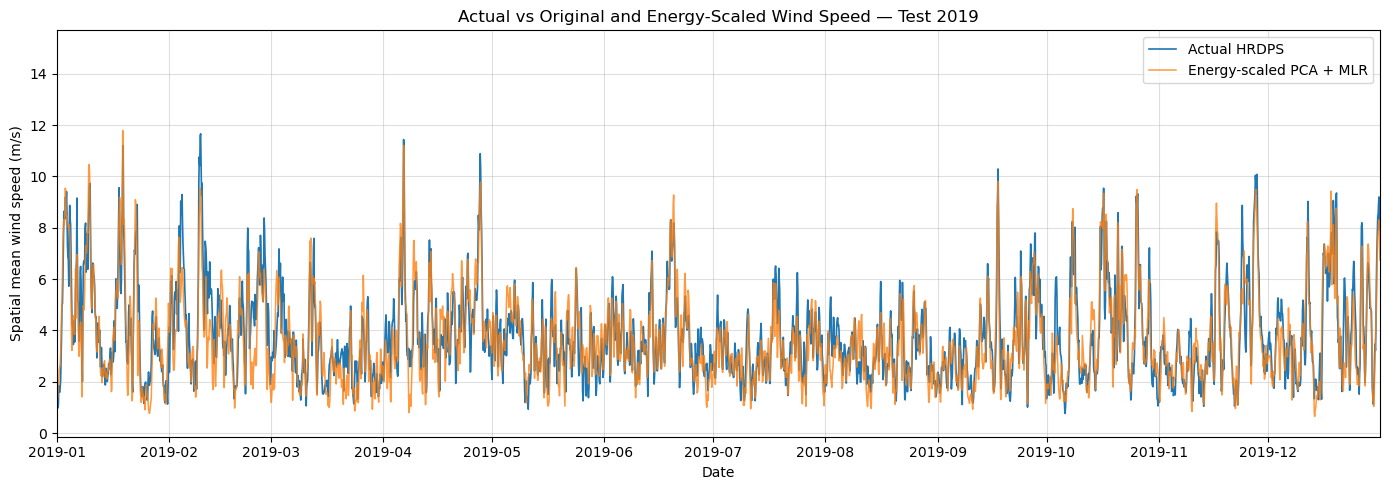

In [66]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    speed_timeseries_test.index,
    speed_timeseries_test["actual"],
    label="Actual HRDPS",
    linewidth=1.2,
)

ax.plot(
    speed_timeseries_test.index,
    speed_timeseries_test["scaled_predicted"],
    label="Energy-scaled PCA + MLR",
    linewidth=1.1,
    alpha=0.8,
)

ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean wind speed (m/s)")
ax.set_title("Actual vs Original and Energy-Scaled Wind Speed — Test 2019")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

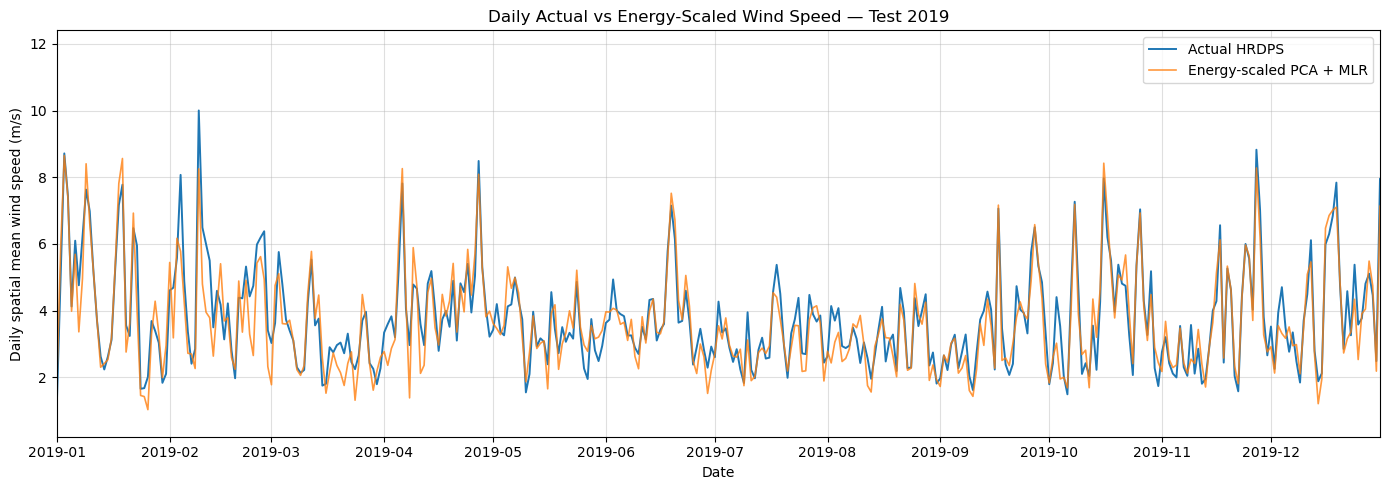

In [67]:
speed_timeseries_test_daily = speed_timeseries_test.resample("1D").mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    speed_timeseries_test_daily.index,
    speed_timeseries_test_daily["actual"],
    label="Actual HRDPS",
    linewidth=1.4,
)

ax.plot(
    speed_timeseries_test_daily.index,
    speed_timeseries_test_daily["scaled_predicted"],
    label="Energy-scaled PCA + MLR",
    linewidth=1.2,
    alpha=0.8,
)

ax.set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31"))
ax.set_xlabel("Date")
ax.set_ylabel("Daily spatial mean wind speed (m/s)")
ax.set_title("Daily Actual vs Energy-Scaled Wind Speed — Test 2019")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

In [68]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)

station_timeseries = {}
station_metrics = []

for station_name, station_info in stations.items():
    column = station_info["column"]

    actual_u = X_hrdps_u_test[:, column]
    actual_v = X_hrdps_v_test[:, column]

    predicted_u_scaled = X_hrdps_u_test_pred_scaled[:, column]
    predicted_v_scaled = X_hrdps_v_test_pred_scaled[:, column]

    actual_speed = np.sqrt(actual_u**2 + actual_v**2)

    predicted_speed_scaled = np.sqrt(predicted_u_scaled**2 + predicted_v_scaled**2)

    station_df = pd.DataFrame(
        {"actual_u": actual_u, 
        "predicted_u_scaled": predicted_u_scaled, 
        "actual_v": actual_v, 
        "predicted_v_scaled": predicted_v_scaled, 
        "actual_speed": actual_speed, 
        "predicted_speed_scaled": predicted_speed_scaled}, index=test_times)

    station_df.index.name = "Date"

    # Scaled RMSE values
    rmse_u_scaled = np.sqrt(mean_squared_error(actual_u, predicted_u_scaled))
    rmse_v_scaled = np.sqrt(mean_squared_error(actual_v, predicted_v_scaled))
    rmse_speed_scaled = np.sqrt(mean_squared_error(actual_speed, predicted_speed_scaled))
    vector_rmse_scaled = np.sqrt(np.mean((predicted_u_scaled - actual_u)**2 + (predicted_v_scaled - actual_v)**2))

    # Standard deviations of actual values
    actual_u_std = np.std(actual_u, ddof=0)
    actual_v_std = np.std(actual_v, ddof=0)
    actual_speed_std = np.std(actual_speed, ddof=0)
    actual_vector_std = np.sqrt(actual_u_std**2 + actual_v_std**2)

    # Normalized scaled RMSE values
    nrmse_u_scaled = rmse_u_scaled / actual_u_std
    nrmse_v_scaled = rmse_v_scaled / actual_v_std
    nrmse_speed_scaled = rmse_speed_scaled / actual_speed_std
    normalized_vector_rmse_scaled = vector_rmse_scaled / actual_vector_std

    station_timeseries[station_name] = station_df

    station_metrics.append({"Station": station_name, "RMSE_u_scaled_mps": rmse_u_scaled, "NRMSE_u_scaled": nrmse_u_scaled, "RMSE_v_scaled_mps": rmse_v_scaled, "NRMSE_v_scaled": nrmse_v_scaled, "RMSE_speed_scaled_mps": rmse_speed_scaled, "NRMSE_speed_scaled": nrmse_speed_scaled, "Vector_RMSE_scaled_mps": vector_rmse_scaled, "Normalized_Vector_RMSE_scaled": normalized_vector_rmse_scaled})

station_rmse_table = pd.DataFrame(station_metrics)

print(station_rmse_table.to_string(index=False))

     Station  RMSE_u_scaled_mps  NRMSE_u_scaled  RMSE_v_scaled_mps  NRMSE_v_scaled  RMSE_speed_scaled_mps  NRMSE_speed_scaled  Vector_RMSE_scaled_mps  Normalized_Vector_RMSE_scaled
  Sand Heads           2.450889        0.595531           1.904640        0.538134               2.113251            0.715776                3.103951                       0.571833
Halibut Bank           2.830396        0.570470           1.665482        0.544407               2.400691            0.793581                3.284048                       0.563410
Sentry Shoal           2.044338        0.491045           2.035843        0.437639               2.215321            0.619924                2.885130                       0.462153


In [69]:
average_station_metrics = station_rmse_table[
    [
        "RMSE_u_scaled_mps",
        "NRMSE_u_scaled",
        "RMSE_v_scaled_mps",
        "NRMSE_v_scaled",
        "RMSE_speed_scaled_mps",
        "NRMSE_speed_scaled",
        "Vector_RMSE_scaled_mps",
        "Normalized_Vector_RMSE_scaled",
    ]
].mean()

print("Average energy-scaled station metrics:")
print(average_station_metrics)

Average energy-scaled station metrics:
RMSE_u_scaled_mps                2.441874
NRMSE_u_scaled                   0.552348
RMSE_v_scaled_mps                1.868655
NRMSE_v_scaled                   0.506727
RMSE_speed_scaled_mps            2.243088
NRMSE_speed_scaled               0.709760
Vector_RMSE_scaled_mps           3.091043
Normalized_Vector_RMSE_scaled    0.532465
dtype: float64


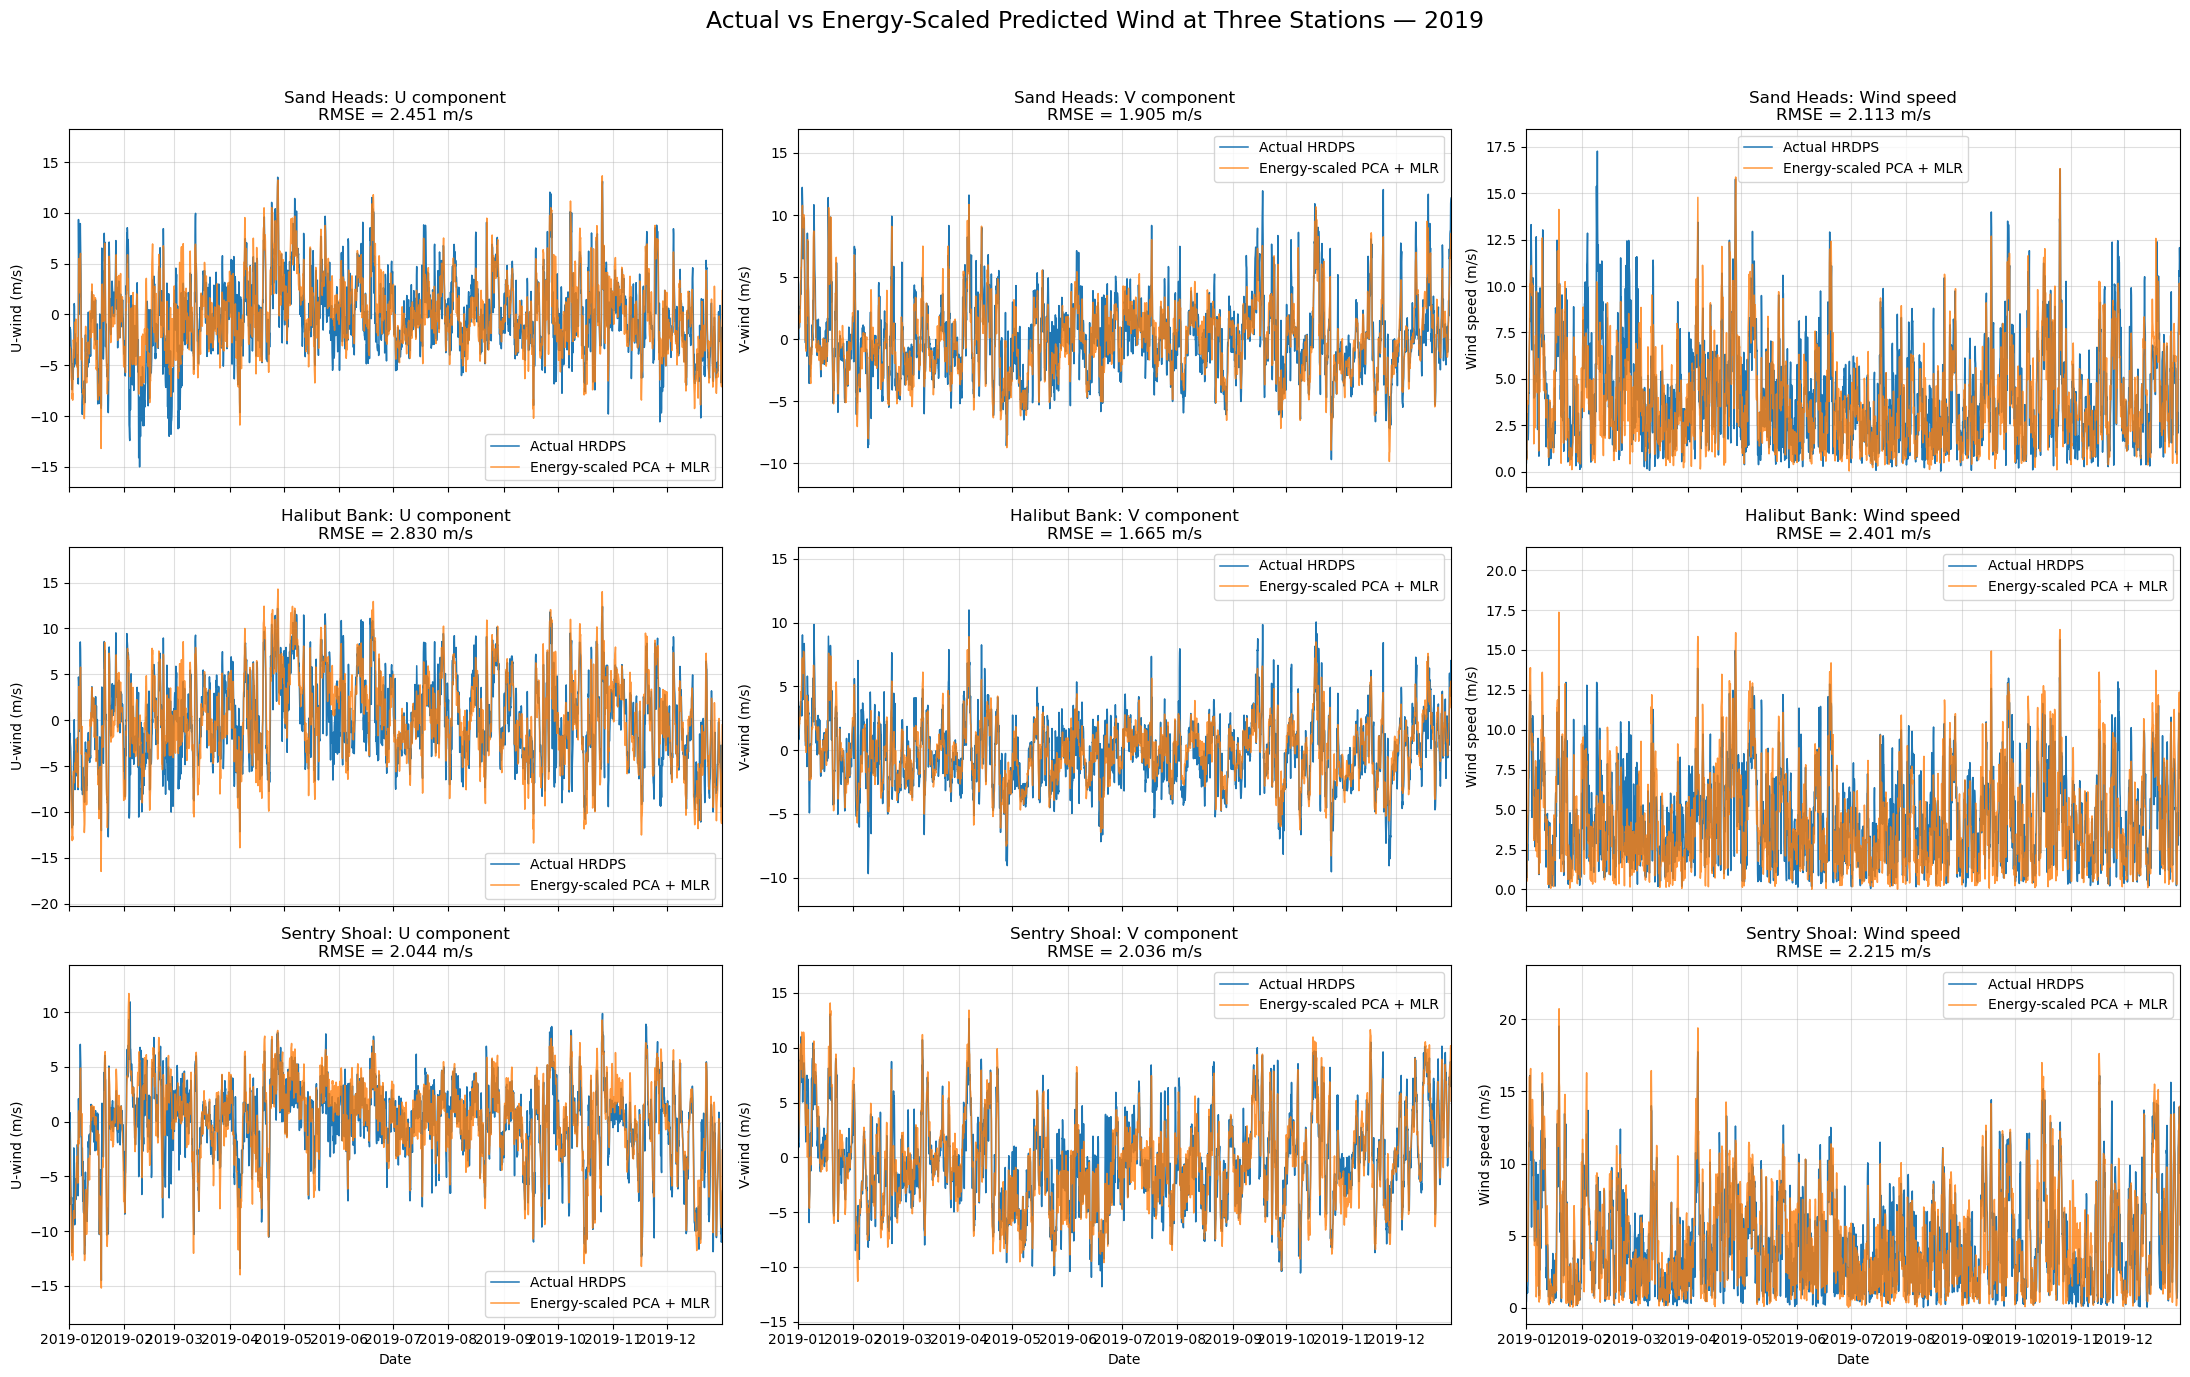

In [70]:
fig, axes = plt.subplots(3, 3, figsize=(22, 14), sharex=True)

for row, (station_name, station_df) in enumerate(station_timeseries.items()):

    scaled_u_rmse = station_rmse_table.loc[station_rmse_table["Station"] == station_name, "RMSE_u_scaled_mps"].iloc[0]
    scaled_v_rmse = station_rmse_table.loc[station_rmse_table["Station"] == station_name, "RMSE_v_scaled_mps"].iloc[0]
    scaled_speed_rmse = station_rmse_table.loc[station_rmse_table["Station"] == station_name, "RMSE_speed_scaled_mps"].iloc[0]

    # U-wind
    axes[row, 0].plot(station_df.index, station_df["actual_u"], label="Actual HRDPS", linewidth=1.1)
    axes[row, 0].plot(station_df.index, station_df["predicted_u_scaled"], label="Energy-scaled PCA + MLR", linewidth=1.1, alpha=0.8)
    axes[row, 0].set_title(f"{station_name}: U component\nRMSE = {scaled_u_rmse:.3f} m/s")
    axes[row, 0].set_ylabel("U-wind (m/s)")
    axes[row, 0].grid(True, alpha=0.4)

    # V-wind
    axes[row, 1].plot(station_df.index, station_df["actual_v"], label="Actual HRDPS", linewidth=1.1)
    axes[row, 1].plot(station_df.index, station_df["predicted_v_scaled"], label="Energy-scaled PCA + MLR", linewidth=1.1, alpha=0.8)
    axes[row, 1].set_title(f"{station_name}: V component\nRMSE = {scaled_v_rmse:.3f} m/s")
    axes[row, 1].set_ylabel("V-wind (m/s)")
    axes[row, 1].grid(True, alpha=0.4)

    # Wind speed
    axes[row, 2].plot(station_df.index, station_df["actual_speed"], label="Actual HRDPS", linewidth=1.1)
    axes[row, 2].plot(station_df.index, station_df["predicted_speed_scaled"], label="Energy-scaled PCA + MLR", linewidth=1.1, alpha=0.8)
    axes[row, 2].set_title(f"{station_name}: Wind speed\nRMSE = {scaled_speed_rmse:.3f} m/s")
    axes[row, 2].set_ylabel("Wind speed (m/s)")
    axes[row, 2].grid(True, alpha=0.4)

    for col in range(3):
        axes[row, col].set_xlim(pd.Timestamp("2019-01-01"), pd.Timestamp("2019-12-31 23:59:59"))
        axes[row, col].legend()

        if row == 2:
            axes[row, col].set_xlabel("Date")

fig.suptitle("Actual vs Energy-Scaled Predicted Wind at Three Stations — 2019", fontsize=17)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [71]:
X_hrdps_u_train_pred_scaled = energy_scaling_constant * X_hrdps_u_train_pred
X_hrdps_v_train_pred_scaled = energy_scaling_constant * X_hrdps_v_train_pred
X_hrdps_u_val_pred_scaled = energy_scaling_constant * X_hrdps_u_val_pred
X_hrdps_v_val_pred_scaled = energy_scaling_constant * X_hrdps_v_val_pred
X_hrdps_u_test_pred_scaled = energy_scaling_constant * X_hrdps_u_test_pred
X_hrdps_v_test_pred_scaled = energy_scaling_constant * X_hrdps_v_test_pred

hrdps_speed_train_pred_scaled = np.sqrt(X_hrdps_u_train_pred_scaled**2 + X_hrdps_v_train_pred_scaled**2)
hrdps_speed_val_pred_scaled = np.sqrt(X_hrdps_u_val_pred_scaled**2 + X_hrdps_v_val_pred_scaled**2)
hrdps_speed_test_pred_scaled = np.sqrt(X_hrdps_u_test_pred_scaled**2 + X_hrdps_v_test_pred_scaled**2)

train_times = pd.to_datetime(ds_hrdps_train["time_counter"].values)
val_times = pd.to_datetime(ds_hrdps_val["time_counter"].values)
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)

predicted_split_data = {
    "Validation": {"years": validation_years, "times": val_times, "values": hrdps_speed_val_pred_scaled},
    "Training": {"years": train_years, "times": train_times, "values": hrdps_speed_train_pred_scaled},
    "Test": {"years": test_years, "times": test_times, "values": hrdps_speed_test_pred_scaled}
}

print("Predicted training wind-speed shape:", hrdps_speed_train_pred_scaled.shape)
print("Predicted validation wind-speed shape:", hrdps_speed_val_pred_scaled.shape)
print("Predicted test wind-speed shape:", hrdps_speed_test_pred_scaled.shape)

Predicted training wind-speed shape: (26280, 81383)
Predicted validation wind-speed shape: (8744, 81383)
Predicted test wind-speed shape: (8760, 81383)


In [72]:
monthly_records = []

for split_name, split_data in predicted_split_data.items():
    predicted_spatial_mean = np.mean(split_data["values"], axis=1)
    predicted_timeseries = pd.DataFrame({"Predicted_Wind_Speed": predicted_spatial_mean}, index=split_data["times"])
    predicted_timeseries.index.name = "Date"
    split_monthly_averages = predicted_timeseries.groupby([predicted_timeseries.index.year, predicted_timeseries.index.month])["Predicted_Wind_Speed"].mean()

    for (year, month), monthly_average in split_monthly_averages.items():
        monthly_records.append({"Year": int(year), "Month": int(month), "Predicted_Monthly_Average_Wind_Speed_mps": float(monthly_average), "Split": split_name})

predicted_monthly_averages = pd.DataFrame(monthly_records)
predicted_monthly_averages = predicted_monthly_averages.sort_values(["Year", "Month"]).reset_index(drop=True)
predicted_monthly_table = predicted_monthly_averages.pivot(index="Year", columns="Month", values="Predicted_Monthly_Average_Wind_Speed_mps")
predicted_monthly_table = predicted_monthly_table.reindex(columns=range(1, 13))
predicted_monthly_table.columns = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

print("Energy-scaled predicted monthly average wind-speed table (m/s):")
print(predicted_monthly_table.round(2).to_string())

Energy-scaled predicted monthly average wind-speed table (m/s):
       Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep   Oct   Nov   Dec
Year                                                                        
2007  4.75  4.42  4.81  3.56  3.57  3.15  3.35  2.82  3.70  4.21  4.14  5.65
2008  5.24  4.28  4.24  3.58  3.48  3.59  3.49  3.30  3.27  3.66  4.42  4.56
2009  4.06  3.48  4.76  3.78  3.66  3.52  3.13  2.96  3.27  4.41  6.11  3.91
2010  4.84  4.21  4.63  4.69  3.76  3.54  3.93  3.18  3.06  3.96  5.04  6.08
2011  3.88  4.97  5.40  4.59  3.35  3.44  3.17  3.12  3.57  3.91  5.29  4.10
2012  5.51  4.53  5.44  3.54  3.60  3.27  3.14  3.12  3.10  3.85  4.97  5.24
2013  3.65  4.30  3.88  4.28  2.85  3.00  3.74  2.87  3.32  3.02  3.65  3.79
2014  3.55  4.78  4.44  3.89  2.90  3.84  3.36  3.18  3.15  4.13  4.59  5.07
2015  3.43  3.74  3.58  3.93  3.15  3.78  3.66  3.60  3.38  3.13  4.45  5.58
2016  4.73  4.33  5.23  3.41  3.79  3.48  3.58  3.45  3.29  4.64  5.58  4.92
2017  4.88  

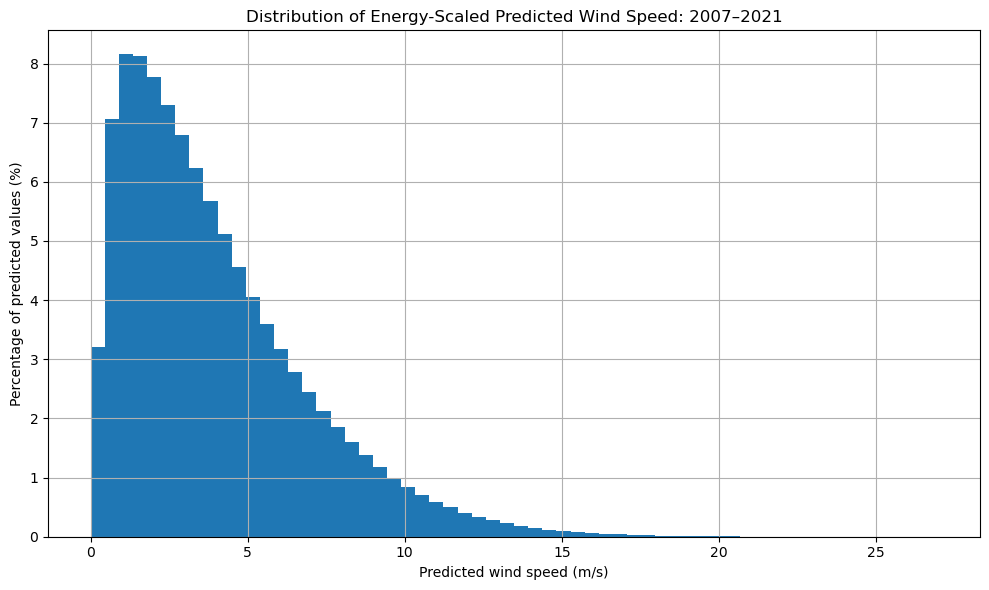

In [73]:
global_predicted_min = min(float(np.min(split_data["values"])) for split_data in predicted_split_data.values())
global_predicted_max = max(float(np.max(split_data["values"])) for split_data in predicted_split_data.values())
histogram_bins = np.linspace(global_predicted_min, global_predicted_max, 61)
all_year_histogram_counts = np.zeros(len(histogram_bins) - 1, dtype=np.int64)

for split_data in predicted_split_data.values():
    split_counts, _ = np.histogram(split_data["values"], bins=histogram_bins)
    all_year_histogram_counts += split_counts

all_year_histogram_percentage = 100 * all_year_histogram_counts / all_year_histogram_counts.sum()

plt.figure(figsize=(10, 6))
plt.stairs(all_year_histogram_percentage, histogram_bins, fill=True)
plt.xlabel("Predicted wind speed (m/s)")
plt.ylabel("Percentage of predicted values (%)")
plt.title("Distribution of Energy-Scaled Predicted Wind Speed: 2007–2021")
plt.grid(True)
plt.tight_layout()
plt.show()

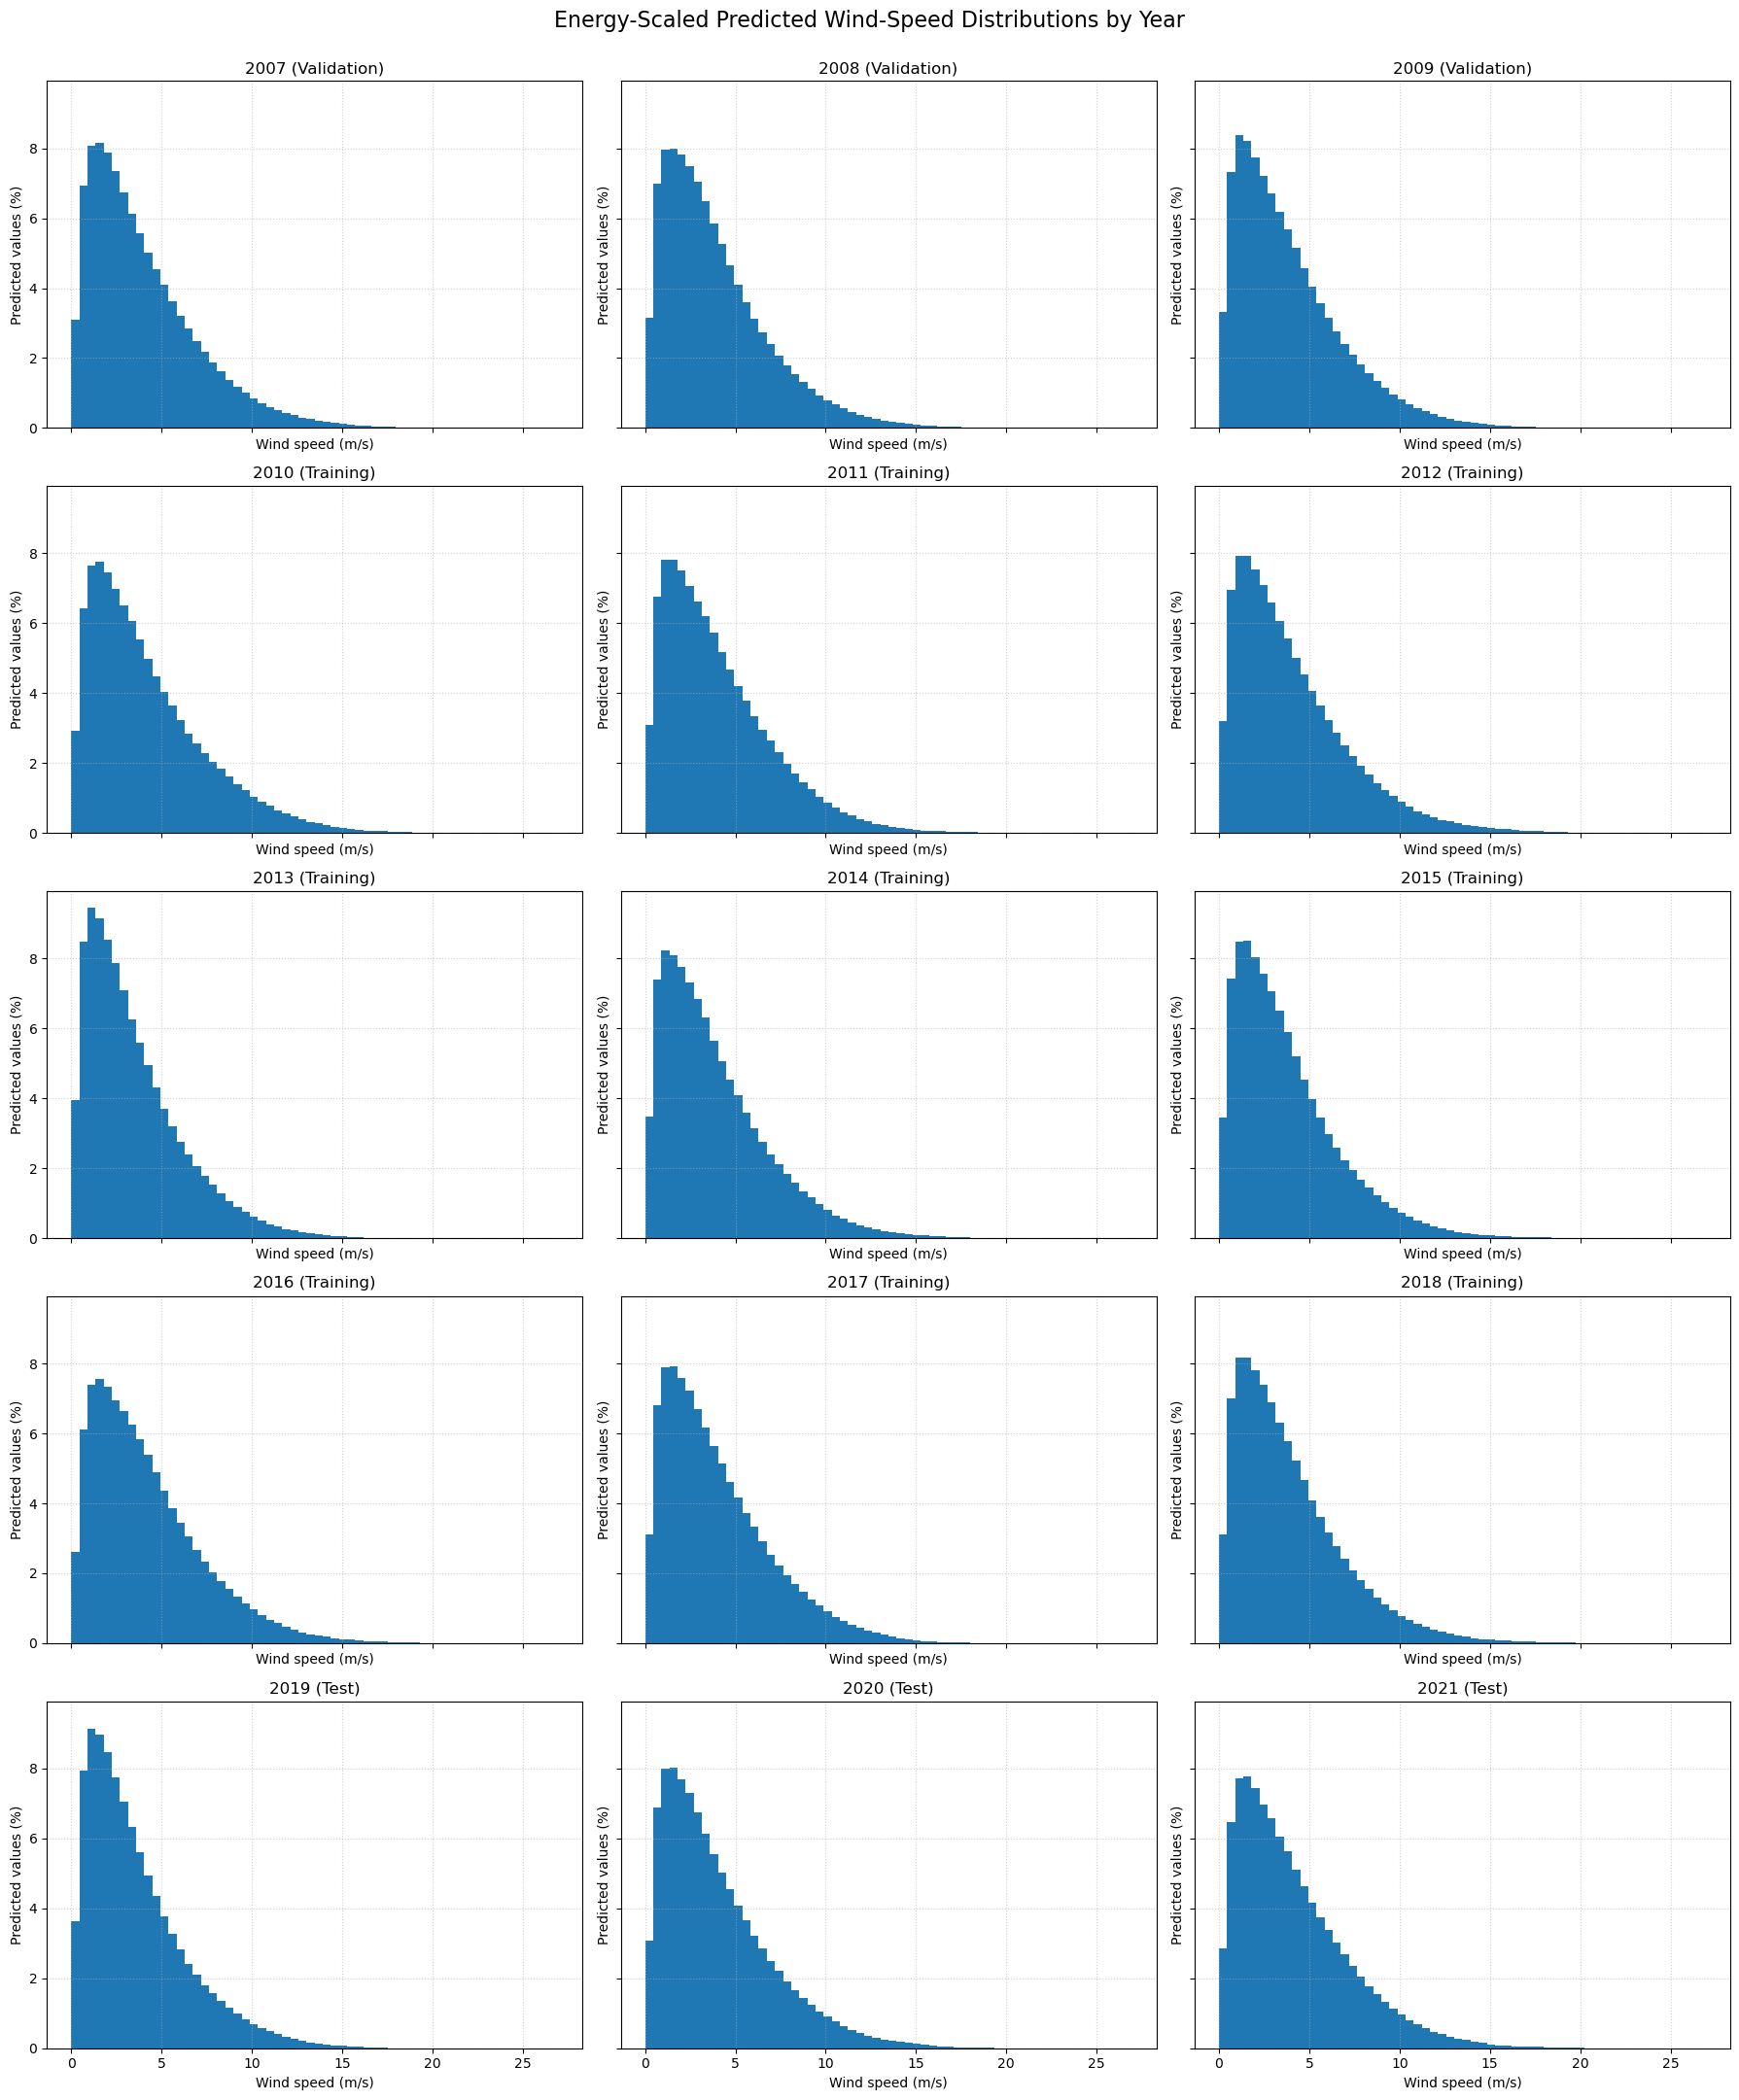

In [74]:
fig, axes = plt.subplots(5, 3, figsize=(18, 22), sharex=True, sharey=True)
axes = axes.ravel()

for ax, year in zip(axes, range(2007, 2022)):
    year_split_name = None
    year_split_data = None

    for split_name, split_data in predicted_split_data.items():
        if year in split_data["years"]:
            year_split_name = split_name
            year_split_data = split_data
            break

    year_positions = np.where(year_split_data["times"].year == year)[0]

    if len(year_positions) == 0:
        ax.set_title(f"{year}: No data")
        continue

    year_predictions = year_split_data["values"][year_positions[0]:year_positions[-1] + 1]
    year_histogram_counts, _ = np.histogram(year_predictions, bins=histogram_bins)
    year_histogram_percentage = 100 * year_histogram_counts / year_histogram_counts.sum()

    ax.stairs(year_histogram_percentage, histogram_bins, fill=True)
    ax.set_title(f"{year} ({year_split_name})")
    ax.set_xlabel("Wind speed (m/s)")
    ax.set_ylabel("Predicted values (%)")
    ax.grid(True, linestyle=":", alpha=0.6)

fig.suptitle("Energy-Scaled Predicted Wind-Speed Distributions by Year", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Actual 2008 wind-speed shape: (2920, 81383)
Predicted 2008 wind-speed shape: (2920, 81383)
Number of 2008 timestamps: 2920
Number of selected spatial points: 16277
Mean wind-speed RMSE across selected points: 1.9641553
Minimum wind-speed RMSE: 0.43092525
Maximum wind-speed RMSE: 2.8815389


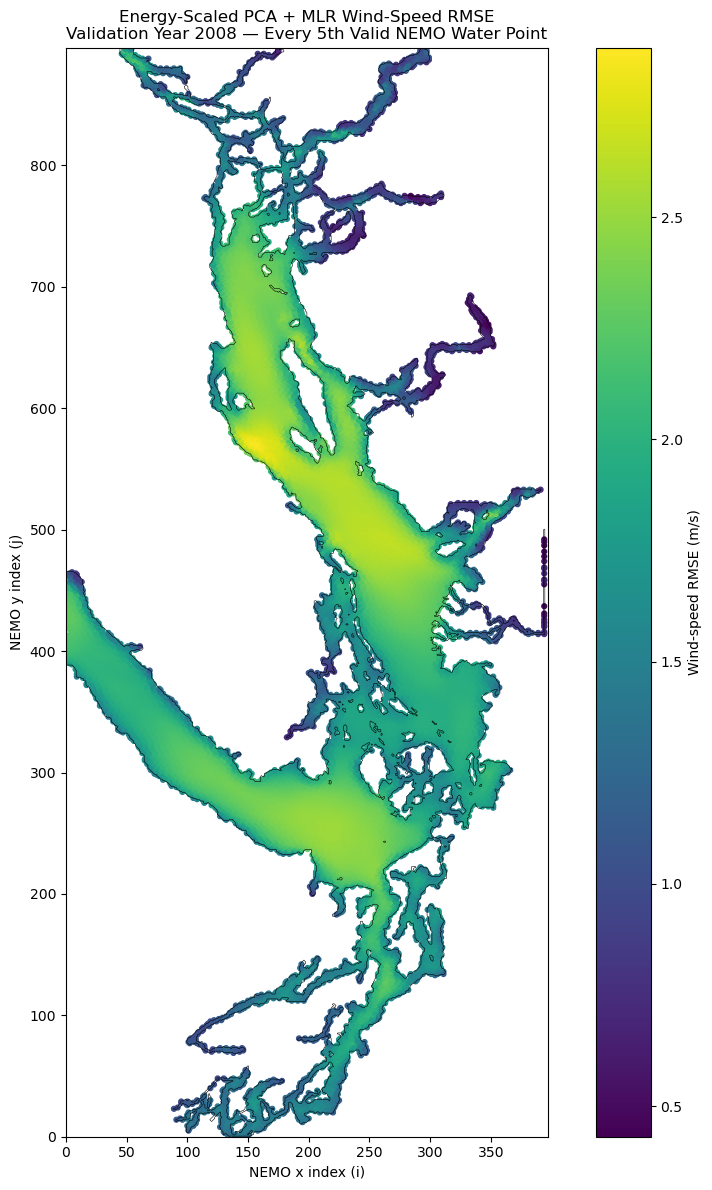

 Matrix_Column  NEMO_j  NEMO_i  Wind_Speed_RMSE_mps
             0       1     134             1.260364
             5       1     139             1.374413
            10       1     144             1.391887
            15       1     149             1.262421
            20       2     133             1.264944
            25       2     140             1.398940
            30       2     145             1.408177
            35       2     151             1.283421
            40       3     131             1.259282
            45       3     136             1.331415
            50       3     145             1.413961
            55       3     150             1.357625
            60       4     130             1.289574
            65       4     135             1.324972
            70       4     145             1.402272
            75       4     150             1.406879
            80       5     101             1.095231
            85       5     133             1.339944
            

In [75]:
validation_year = 2008
spatial_step = 5

val_times = pd.to_datetime(ds_hrdps_val["time_counter"].values)
year_time_mask = val_times.year == validation_year

if not np.any(year_time_mask):
    raise ValueError(f"No validation data found for {validation_year}.")

X_actual_speed_2008 = hrdps_speed_val[year_time_mask]
X_predicted_speed_2008 = hrdps_speed_val_pred_scaled[year_time_mask]

print("Actual 2008 wind-speed shape:", X_actual_speed_2008.shape)
print("Predicted 2008 wind-speed shape:", X_predicted_speed_2008.shape)
print("Number of 2008 timestamps:", np.sum(year_time_mask))

if X_actual_speed_2008.shape != X_predicted_speed_2008.shape:
    raise ValueError("Actual and predicted 2008 wind-speed matrices do not have matching shapes.")

if X_actual_speed_2008.shape[1] != len(valid_nemo_j):
    raise ValueError("The number of matrix columns does not match valid_nemo_j.")

if X_actual_speed_2008.shape[1] != len(valid_nemo_i):
    raise ValueError("The number of matrix columns does not match valid_nemo_i.")

selected_columns = np.arange(0, X_actual_speed_2008.shape[1], spatial_step)

actual_selected = X_actual_speed_2008[:, selected_columns]
predicted_selected = X_predicted_speed_2008[:, selected_columns]

finite_pairs = np.isfinite(actual_selected) & np.isfinite(predicted_selected)
squared_errors = np.where(finite_pairs, (predicted_selected - actual_selected)**2, np.nan)
rmse_every_5th_point = np.sqrt(np.nanmean(squared_errors, axis=0))

selected_nemo_j = valid_nemo_j[selected_columns]
selected_nemo_i = valid_nemo_i[selected_columns]

print("Number of selected spatial points:", len(selected_columns))
print("Mean wind-speed RMSE across selected points:", np.nanmean(rmse_every_5th_point))
print("Minimum wind-speed RMSE:", np.nanmin(rmse_every_5th_point))
print("Maximum wind-speed RMSE:", np.nanmax(rmse_every_5th_point))

fig, ax = plt.subplots(figsize=(10, 12))

ax.contour(water_mask.astype(int), levels=[0.5], colors="black", linewidths=0.4)

scatter = ax.scatter(selected_nemo_i, selected_nemo_j, c=rmse_every_5th_point, cmap="viridis", s=12, marker="o")

colorbar = plt.colorbar(scatter, ax=ax)
colorbar.set_label("Wind-speed RMSE (m/s)")

ax.set_xlabel("NEMO x index (i)")
ax.set_ylabel("NEMO y index (j)")
ax.set_title("Energy-Scaled PCA + MLR Wind-Speed RMSE\nValidation Year 2008 — Every 5th Valid NEMO Water Point")

ax.set_xlim(0, water_mask.shape[1] - 1)
ax.set_ylim(0, water_mask.shape[0] - 1)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

rmse_every_5th_point_table = pd.DataFrame({
    "Matrix_Column": selected_columns,
    "NEMO_j": selected_nemo_j,
    "NEMO_i": selected_nemo_i,
    "Wind_Speed_RMSE_mps": rmse_every_5th_point
})

print(rmse_every_5th_point_table.head(20).to_string(index=False))